<a href="https://colab.research.google.com/github/AliciaGalindo-max/TC4058.10-IAyAA/blob/main/ActividadSemana3_A00784113.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Maestría en Inteligencia Artificial Aplicada**

## **Curso: Inteligencia Artificial y Aprendizaje Automático**

**Tecnológico de Monterrey**

Prof Luis Eduardo Falcón Morales

Actividad de Semana 3

### **Rotación de Personal - IBM**

|Matrícula| Nombre                         |
|---------|--------------------------------|
A00784113 | Alicia Fernanda Galindo Manrique

------------

* #### **En esta actividad puedes apoyarte en uno o varios Modelos de Lenguaje de Gran Tamaño, LLM por sus siglas en inglés (Large Language Model). Indica claramente cuál o cuáles utilizaste.**

* #### **La siguiente actividad se basa en los datos del archivo "WA_Fn-UseC_-HR-Employee-Attrition.csv" que se encuentra en la siguiente liga de Kaggle, llamada "IBM HR Analytics Employee Attrition & Performance".**

* #### **Los datos los proporcionó IBM y aunque comentaron que por cuestiones de privacidad los datos son sintéticos, los generaron con base a su experiencia. Estos datos en general son referencia cuando se habla en Estadística o Aprendizaje Automático sobre el tema de rotación de personal.**

**El archivo contiene 1470 registros:**

https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset


# **Ejercicio 1:**

#### **Incluye una breve introducción sobre lo que se entiende por el problema de rotación de personal en las organizaciones (employee attrition problem).**

++++++++ Inicia la sección de agregar texto: +++++
+++++++


Respuesta:
# **Ejercicio 1: Introducción**

La **rotación de personal** (*employee attrition*) se refiere a la salida de
empleados de una organización, ya sea por renuncia voluntaria, despido,
jubilación u otras causas, y a la consecuente necesidad de reemplazarlos o
de absorber la pérdida de esa capacidad de trabajo. Suele distinguirse entre
rotación **voluntaria** (el empleado decide irse) e **involuntaria** (la
organización termina la relación), y entre rotación **funcional** (salen
empleados de bajo desempeño) y **disfuncional** (salen empleados valiosos).
El problema de interés para las organizaciones es principalmente la rotación
voluntaria y disfuncional.

Su relevancia radica en los costos que genera: costos directos de
reclutamiento, selección y capacitación del reemplazo, y costos indirectos
como la pérdida de conocimiento y experiencia, la caída de productividad
durante la curva de aprendizaje, la sobrecarga de quienes permanecen y el
posible deterioro del clima laboral y del servicio al cliente.

Entre los factores comúnmente asociados a la rotación se encuentran la
compensación, la satisfacción con el trabajo y con el ambiente laboral, las
oportunidades de desarrollo y promoción, la carga de trabajo y las horas
extra, el balance entre vida personal y trabajo, la relación con el jefe
directo, la antigüedad y características demográficas como la edad.

**Para resolver esta actividad es importante considerar lo siguiente: **
Desde la perspectiva del Aprendizaje Automático, el problema se plantea como
una tarea de **clasificación binaria supervisada**: a partir de las
características de cada empleado se busca predecir si dejará la organización
(`Attrition = Yes`) o permanecerá (`Attrition = No`). El objetivo es doble:
**predecir** qué empleados están en riesgo de salir e **identificar los
factores** que más influyen, para diseñar acciones de retención. Una
dificultad característica es el **desbalance de clases**, ya que normalmente
los empleados que se van son una minoría, por lo que la exactitud (*accuracy*)
por sí sola no es una métrica adecuada y deben considerarse otras como
*recall*, *precision*, F1 o AUC.

En esta actividad se utiliza el conjunto de datos sintético *IBM HR Analytics
Employee Attrition & Performance*, con 1470 registros de empleados.





++++++++ Termina la sección de agregar texto. +++++++++++

In [1]:
# Agrega aquí todas las librerías adicionales o paquetes que consideres necesarias:

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn import metrics

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier


from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PowerTransformer
from sklearn.impute import SimpleImputer

from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import cross_validate

from sklearn.preprocessing import OrdinalEncoder

from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report



* #### **Descarga el archivo de datos de la página de Kaggle.**

* #### **Cargamos el archivo como un DataFrame de Pandas y hacemos uso del método “describe” con el argumento include= “all” para desplegar información de todas las variables, numéricas y categóricas.**

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("pavansubhasht/ibm-hr-analytics-attrition-dataset")

print("Path to dataset files:", path)




Using Colab cache for faster access to the 'ibm-hr-analytics-attrition-dataset' dataset.
Path to dataset files: /kaggle/input/ibm-hr-analytics-attrition-dataset


In [5]:
import os
import pandas as pd

path = os.path.join("/kaggle/input/ibm-hr-analytics-attrition-dataset",
                    "WA_Fn-UseC_-HR-Employee-Attrition.csv")
data = pd.read_csv(path)

print("Tamaño del DataFrame:", data.shape)
data.describe(include='all').T

Tamaño del DataFrame: (1470, 35)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,1470.0,NaN,NaN,NaN,36.92381,9.135373,18.0,30.0,36.0,43.0,60.0
Attrition,1470,2,No,1233,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BusinessTravel,1470,3,Travel_Rarely,1043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DailyRate,1470.0,NaN,NaN,NaN,802.485714,403.5091,102.0,465.0,802.0,1157.0,1499.0
Department,1470,3,Research & Development,961,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DistanceFromHome,1470.0,NaN,NaN,NaN,9.192517,8.106864,1.0,2.0,7.0,14.0,29.0
Education,1470.0,NaN,NaN,NaN,2.912925,1.024165,1.0,2.0,3.0,4.0,5.0
EducationField,1470,6,Life Sciences,606,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EmployeeCount,1470.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
EmployeeNumber,1470.0,NaN,NaN,NaN,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0


# **Ejercicio 2:**

**a) Realiza los análisis descriptivos y/o gráficos que creas adecuados para identificar 4 factores que se deben eliminar desde un inicio.**

**Al nuevo DataFrame sin las variables indicadas, llamarlo df.**



In [ ]:
# a) Incluye a continuación el código y celdas que creas adecuados para responder a la pregunta.

# ++++++++++ Inicia sección para agregar tu código ++++++++++++++++++++++++


# Número de valores únicos, tipo de dato y datos perdidos por variable
resumen = pd.DataFrame({
    "tipo": data.dtypes,
    "valores_unicos": data.nunique(),
    "datos_perdidos": data.isnull().sum()
}).sort_values("valores_unicos")

resumen

# Variables con un solo valor (varianza cero)
constantes = [c for c in data.columns if data[c].nunique() == 1]
print("Variables constantes:", constantes)
for c in constantes:
    print(f"  {c}: valor único = {data[c].unique()[0]}")

# Variables con un valor distinto por registro (identificadores)
ids = [c for c in data.columns if data[c].nunique() == len(data)]
print("\nVariables identificadoras:", ids)

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
for ax, c in zip(axes, ["EmployeeCount", "StandardHours", "Over18", "EmployeeNumber"]):
    if c == "EmployeeNumber":
        ax.plot(data[c].values)          # crece con el índice: es un folio
        ax.set_xlabel("índice del registro")
    else:
        data[c].value_counts().plot(kind="bar", ax=ax)
    ax.set_title(c)
plt.tight_layout()
plt.show()

eliminar = ["EmployeeCount", "StandardHours", "Over18", "EmployeeNumber"]
df = data.drop(columns=eliminar)

print("Tamaño original:", data.shape)
print("Tamaño de df:   ", df.shape)


# ++++++++++ Termina sección para agregar código +++++++++++++++++++++++++++


# Verifiquemos de qué tamaño queda el nuevo DataFrame:
print("Tamaño del nuevo DataFrame:", df.shape)

In [6]:
# Número de valores únicos, tipo de dato y datos perdidos por variable
resumen = pd.DataFrame({
    "tipo": data.dtypes,
    "valores_unicos": data.nunique(),
    "datos_perdidos": data.isnull().sum()
}).sort_values("valores_unicos")

resumen

,tipo,valores_unicos,datos_perdidos
EmployeeCount,int64,1,0
Over18,object,1,0
StandardHours,int64,1,0
Attrition,object,2,0
OverTime,object,2,0
PerformanceRating,int64,2,0
Gender,object,2,0
BusinessTravel,object,3,0
Department,object,3,0
MaritalStatus,object,3,0


In [7]:
# Variables con un solo valor (varianza cero)
constantes = [c for c in data.columns if data[c].nunique() == 1]
print("Variables constantes:", constantes)
for c in constantes:
    print(f"  {c}: valor único = {data[c].unique()[0]}")

# Variables con un valor distinto por registro (identificadores)
ids = [c for c in data.columns if data[c].nunique() == len(data)]
print("\nVariables identificadoras:", ids)

Variables constantes: ['EmployeeCount', 'Over18', 'StandardHours']
  EmployeeCount: valor único = 1
  Over18: valor único = Y
  StandardHours: valor único = 80

Variables identificadoras: ['EmployeeNumber']


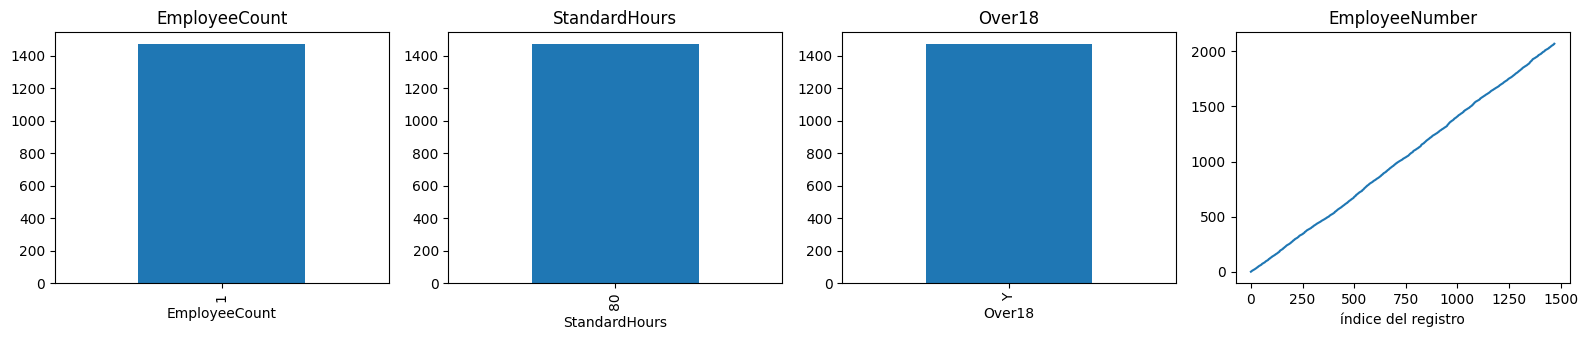

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
for ax, c in zip(axes, ["EmployeeCount", "StandardHours", "Over18", "EmployeeNumber"]):
    if c == "EmployeeNumber":
        ax.plot(data[c].values)          # crece con el índice: es un folio
        ax.set_xlabel("índice del registro")
    else:
        data[c].value_counts().plot(kind="bar", ax=ax)
    ax.set_title(c)
plt.tight_layout()
plt.show()

In [9]:
eliminar = ["EmployeeCount", "StandardHours", "Over18", "EmployeeNumber"]
df = data.drop(columns=eliminar)

print("Tamaño original:", data.shape)
print("Tamaño de df:   ", df.shape)

Tamaño original: (1470, 35)
Tamaño de df:    (1470, 31)


**b) Con base a tu análisis anterior, indica cuáles fueron estas 4 variables y la justificación de por qué se pueden eliminar.**

++++++++ Inicia la sección de agregar texto: ++++++++++++

**

**Justificación de los 4 factores eliminados**

- **EmployeeCount**: toma el valor 1 en los 1470 registros. Al ser constante
  tiene varianza cero y no aporta información para distinguir entre empleados
  que se van y los que permanecen.
- **StandardHours**: toma el valor 80 en todos los registros. Por la misma
  razón, no tiene capacidad discriminante.
- **Over18**: toma el valor "Y" en todos los registros (todos los empleados
  son mayores de edad). Es constante y además redundante con la variable Age.
- **EmployeeNumber**: tiene 1470 valores distintos, uno por registro. Es un
  identificador administrativo sin relación causal con la rotación; incluirlo
  solo añadiría ruido y riesgo de sobreajuste, ya que un modelo podría
  memorizar registros individuales.

Ninguna variable presenta datos perdidos, por lo que no se eliminan factores
por ese motivo. El nuevo DataFrame `df` conserva 31 columnas: 30 factores y
la variable objetivo `Attrition`.


  ++++++++ Termina la sección de agregar texto: ++++++++++++

# **Ejercicio 3:**

#### **Una vez eliminadas las variables no deseadas, clasifiquemos las restantes como se indica a continuación y en base a la información dada en la plataforma de Kaggle.**

#### **El número entre corcheas indica el número de variables de dicho tipo y el  número entre paréntesis redondos indica el número de niveles.**

* **Variables numéricas [14]:**

   * NumCompaniesWorked

   * TrainingTimesLastYear

   * Age

   * DailyRate

   * DistanceFromHome

   * HourlyRate

   * MonthlyIncome

   * MonthlyRate

   * PercentSalaryHike

   * TotalWorkingYears

   * YearsAtCompany

   * YearsInCurrentRole

   * YearsSinceLastPromotion

   * YearsWithCurrManager

* **Variables ordinales [9]:**

   * Education (5)

   * EnvironmentSatisfaction (4)

   * JobInvolvement (4)

   * JobLevel (5)

   * JobSatisfaction (4)

   * PerformanceRating (2)

   * RelationshipSatisfaction (4)

   * StockOptionLevel (4)

   * WorkLifeBalance (4)

* **Variables binarias [3]:**

   * Attrition (variable de salida)

   * Gender

   * OverTime

* **Variables nominales [5]:**

   * BusinessTravel (3)

   * Department (3)

   * EducationField (6)

   * JobRole (9)

   * MaritalStatus (3)

In [10]:
num_vars = ["NumCompaniesWorked", "TrainingTimesLastYear", "Age", "DailyRate",
            "DistanceFromHome", "HourlyRate", "MonthlyIncome", "MonthlyRate",
            "PercentSalaryHike", "TotalWorkingYears", "YearsAtCompany",
            "YearsInCurrentRole", "YearsSinceLastPromotion", "YearsWithCurrManager"]

ord_vars = ["Education", "EnvironmentSatisfaction", "JobInvolvement", "JobLevel",
            "JobSatisfaction", "PerformanceRating", "RelationshipSatisfaction",
            "StockOptionLevel", "WorkLifeBalance"]

bin_vars = ["Attrition", "Gender", "OverTime"]      # Attrition es la variable de salida

nom_vars = ["BusinessTravel", "Department", "EducationField", "JobRole", "MaritalStatus"]

# Verificación: todas las columnas de df quedan clasificadas, sin repetir ni faltar
todas = num_vars + ord_vars + bin_vars + nom_vars
print("Total clasificadas:", len(todas), "| Columnas en df:", df.shape[1])
print("Faltan por clasificar:", set(df.columns) - set(todas))
print("No existen en df:     ", set(todas) - set(df.columns))

# Verificación del número de niveles de las variables categóricas
df[ord_vars + bin_vars + nom_vars].nunique()

Total clasificadas: 31 | Columnas en df: 31
Faltan por clasificar: set()
No existen en df:      set()


,0
Education,5
EnvironmentSatisfaction,4
JobInvolvement,4
JobLevel,5
JobSatisfaction,4
PerformanceRating,2
RelationshipSatisfaction,4
StockOptionLevel,4
WorkLifeBalance,4
Attrition,2


**Indpendientemente de los factores que al final el modelo identifique como los factores más importantes a considerar en este problema de rotación de personal ¿qué preocupaciones éticas o legales podrían generarse, si algunos de estos factores más importantes a considerar para tomar decisiones sobre los empleados fueran la edad (Age), el género (Gender) o el estado civil (Marital Status)?**


++++++++ Inicia la sección de agregar texto: ++++++++++++


**Preocupaciones éticas y legales**

La edad, el género y el estado civil son **características protegidas** en la
mayoría de las legislaciones laborales. Usarlas para tomar decisiones sobre
empleados genera las siguientes preocupaciones:

**Legales**

- **Discriminación laboral.** En México, el artículo 1.º constitucional, la
  Ley Federal del Trabajo (arts. 2, 3 y 133) y la Ley Federal para Prevenir y
  Eliminar la Discriminación prohíben distinguir entre trabajadores por edad,
  género o estado civil. En Estados Unidos aplican el Título VII de la Ley de
  Derechos Civiles (1964) y la Ley contra la Discriminación por Edad en el
  Empleo (ADEA, 1967); en la Unión Europea, las directivas de igualdad de
  trato.
- **Impacto dispar.** Aun sin intención de discriminar, una política basada en
  el modelo puede ser ilegal si perjudica de forma desproporcionada a un grupo
  protegido (por ejemplo, invertir menos en capacitación para empleados
  jóvenes o solteros porque el modelo los marca como de "alto riesgo").
- **Decisiones automatizadas y datos personales.** El RGPD europeo (art. 22)
  limita las decisiones basadas únicamente en tratamiento automatizado, y el
  Reglamento de IA de la UE clasifica los sistemas usados en gestión de
  personal como de alto riesgo. En México, la legislación de protección de
  datos personales exige consentimiento y finalidad legítima para su uso.

**Éticas**

- **Justicia.** Se juzga a la persona por el comportamiento estadístico de su
  grupo y no por su conducta o desempeño individual, sobre atributos que no
  puede o no debería tener que cambiar.
- **Perpetuación de sesgos.** El modelo aprende de datos históricos; si la
  rotación de ciertos grupos se debió a un trato desigual previo, el modelo lo
  reproduce y lo legitima con apariencia de objetividad.
- **Profecía autocumplida.** Negar promociones o desarrollo a quien el modelo
  marca como "probable que se vaya" aumenta precisamente su probabilidad de
  irse.
- **Transparencia y consentimiento.** Los empleados rara vez saben que se les
  evalúa con un modelo ni pueden impugnar el resultado.

**Consideración adicional: variables proxy.** Eliminar estas tres variables no
resuelve el problema por completo, ya que otras pueden actuar como sustitutos:
`TotalWorkingYears` y `YearsAtCompany` se correlacionan con la edad, y
`JobRole` o `Department` pueden correlacionarse con el género.

**Postura.** Estos factores pueden analizarse de forma **agregada** para
diagnosticar problemas organizacionales (por ejemplo, detectar que un grupo
abandona más la empresa e investigar por qué), pero no deben utilizarse para
tomar decisiones **individuales** sobre contratación, promoción, compensación
o despido. Además, conviene auditar el modelo con métricas de equidad por
grupo y mantener supervisión humana en las decisiones.



++++++++ Termina la sección de agregar texto. +++++++++++


# **Ejercicio 4:**

**a) Aunque este problema como está planteado es un problema de clasificación binaria, ¿qué otros enfoques analíticos podrían plantearse y modelarse a partir de este problema? Menciona al menos dos más.**



++++++++ Inicia la sección de agregar texto: ++++++++++++

**

**Otros enfoques analíticos para el problema de rotación**

1. **Análisis de supervivencia (tiempo hasta el evento).** En lugar de
   preguntar *si* el empleado se va, se modela *cuándo* se va. La variable
   `YearsAtCompany` sería el tiempo observado y `Attrition` el indicador del
   evento; los empleados que siguen en la empresa se tratan como
   observaciones censuradas. Con curvas de Kaplan-Meier o un modelo de riesgos
   proporcionales de Cox se estima cómo cada factor acelera o retrasa la
   salida, lo que permite intervenir en el momento oportuno.

2. **Segmentación mediante aprendizaje no supervisado (clustering).** Sin usar
   la variable de salida, se agrupan los empleados en perfiles homogéneos (por
   ejemplo con K-means o agrupamiento jerárquico) y después se compara la tasa
   de rotación entre grupos. Permite diseñar estrategias de retención
   diferenciadas por perfil en lugar de una política única.

3. **Regresión.** Se puede predecir una variable continua relacionada con la
   rotación: los años de permanencia esperados (`YearsAtCompany`), el nivel de
   satisfacción laboral como indicador anticipado, o el costo económico
   esperado de la salida de cada empleado.

4. **Estimación de probabilidad y ordenamiento por riesgo (scoring).** En vez
   de una etiqueta Sí/No, se usa la probabilidad estimada para ordenar a los
   empleados por nivel de riesgo y priorizar las acciones de retención según
   el presupuesto disponible.

5. **Inferencia causal.** Los modelos predictivos identifican asociaciones, no
   causas. Con técnicas causales (emparejamiento por puntaje de propensión,
   modelos *uplift*) se estima el efecto de una intervención concreta, por
   ejemplo: ¿reducir las horas extra disminuye realmente la rotación?

6. **Detección de anomalías.** Dado que los empleados que se van son una

   minoría, puede plantearse como la identificación de casos atípicos
   respecto al patrón del empleado que permanece (Isolation Forest,
   One-Class SVM).


  ++++++++ Termina la sección de agregar texto: ++++++++++++

### **Para esta actividad usaremos una partición en Train, Val y Test, con los porcentajes que se indican a continuación.**

In [11]:
print("Dimensiones y Porcentajes de la partición Train+Validation+Test generada:")
print("-"*75)

X = df.drop(columns='Attrition')
y = df[['Attrition']]

Xtrain, Xtv, ytrain, ytv = train_test_split(X, y, train_size=0.70, stratify=y, random_state=17)
Xval, Xtest, yval, ytest = train_test_split(Xtv, ytv, test_size=0.5, stratify=ytv, random_state=17)

print("Variables de entrada Train, Validation, Test:")
print(Xtrain.shape, '%.1f%%' % (100.*Xtrain.shape[0]/X.shape[0]))
print(Xval.shape, '%.1f%%' % (100.*Xval.shape[0]/X.shape[0])),
print(Xtest.shape, '%.1f%%' % (100.*Xtest.shape[0]/X.shape[0]))

print("\nVariables de salida Train, Validation, Test:")
print(ytrain.shape)
print(yval.shape)
print(ytest.shape)

Dimensiones y Porcentajes de la partición Train+Validation+Test generada:
---------------------------------------------------------------------------
Variables de entrada Train, Validation, Test:
(1029, 30) 70.0%
(220, 30) 15.0%
(221, 30) 15.0%

Variables de salida Train, Validation, Test:
(1029, 1)
(220, 1)
(221, 1)


# **Ejercicio 5:**


**a) Aplica la transformación LabelEncoder() de Sklearn a la variable“Attrition”, tomando en cuenta los siguientes puntos:**

* **Las nuevas variables deberán llamarse ahora: ytrainT, yvalT, ytestT.**

* **Al aplicar la transformación LabelEncoder deberás evitar el filtrado de información (data-leakage).**


In [14]:
# a)
# ++++++++++ Inicia sección para agregar tu código ++++++++++++++++++++++++


from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# El codificador se ajusta (fit) SOLO con el conjunto de entrenamiento
le.fit(ytrain['Attrition'])

# Los tres conjuntos se transforman con el codificador ya ajustado,
# conservando el formato DataFrame y el índice original
ytrainT = pd.DataFrame(le.transform(ytrain['Attrition']), columns=['Attrition'], index=ytrain.index)
yvalT   = pd.DataFrame(le.transform(yval['Attrition']),   columns=['Attrition'], index=yval.index)
ytestT  = pd.DataFrame(le.transform(ytest['Attrition']),  columns=['Attrition'], index=ytest.index)

print("Clases aprendidas:", le.classes_)
print("Codificación:", {c: int(v) for c, v in zip(le.classes_, le.transform(le.classes_))})
print("\nDimensiones:", ytrainT.shape, yvalT.shape, ytestT.shape)


# +++++++++++++++++ Termina sección para agregar tu código ++++++++++++++++++++++++


print('Porcentaje de datos en cada clase del conjunto de entrenamiento (Train):\n', ytrainT['Attrition'].value_counts() / ytrainT.shape[0])

Clases aprendidas: ['No' 'Yes']
Codificación: {'No': 0, 'Yes': 1}

Dimensiones: (1029, 1) (220, 1) (221, 1)
Porcentaje de datos en cada clase del conjunto de entrenamiento (Train):
 Attrition
0    0.838678
1    0.161322
Name: count, dtype: float64


#### Además, responde las siguientes preguntas:

**b) Con base a la documentación actual de Sklearn, ¿a qué tipo de variables se recomienda aplicar la transformación LabelEncoder?**



**c) Con base al contexto del problema, ¿qué significan los valores 0 (NO) y 1 (YES) de la variable de salida Attrition?**



**d) Con base a la información obtenida y considerando la métrica de la exactitud (accuracy) ¿cuál será el valor del umbral del modelo base o ingenuo (baseline, naive) a superar para evitar tener un modelo subentrenado una vez que empecemos a generarlos?**



**d) Umbral del modelo base (baseline)**


**e) Indica si el desbalanceo de clases obtenido puede ya considerarse como un problema, y de considerarlo así, qué otra métrica o métricas podrían ser más adecuadas que la exactitud (accuracy).**


**e) Desbalanceo de clases y métricas alternativas**


++++++++ Inicia la sección de agregar texto: ++++++++++++

**b) Variables a las que se recomienda aplicar LabelEncoder**

De acuerdo con la documentación actual de scikit-learn (versión 1.9.1),
`LabelEncoder` debe utilizarse para codificar la **variable de salida
(objetivo), es decir `y`, y no las variables de entrada `X`**. Codifica las
etiquetas con valores entre 0 y n_clases − 1. Para las variables categóricas
de entrada, la documentación remite a `OrdinalEncoder` y `OneHotEncoder`.

Fuente: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html

**c) Significado de los valores 0 y 1**

- **0 (No):** el empleado **permanece** en la organización; no hubo rotación.
  Es la clase negativa y mayoritaria.
- **1 (Yes):** el empleado **dejó** la organización; sí hubo rotación. Es la
  clase positiva y minoritaria, y la de mayor interés para el negocio, ya que
  son los casos que se busca anticipar para aplicar acciones de retención.

**d) Umbral del modelo base (baseline)**

El modelo ingenuo es aquel que predice siempre la clase mayoritaria (0, No),
sin usar ningún factor de entrada. Su exactitud es igual a la proporción de
esa clase en el conjunto de entrenamiento: **83.9 %** (863 de 1029
registros). Por lo tanto, cualquier modelo debe superar una exactitud de
aproximadamente **0.839**; un modelo con exactitud igual o menor no estaría
aprendiendo nada útil de los datos y se consideraría subentrenado.

**e) Desbalanceo de clases y métricas alternativas**

Sí puede considerarse un problema. La distribución es de aproximadamente
84 % / 16 % (razón cercana a 5:1), un desbalanceo moderado pero suficiente
para que la exactitud resulte engañosa: el modelo ingenuo alcanza 83.9 % de

exactitud y, sin embargo, no identifica a **ninguno** de los empleados que se
van (recall = 0 en la clase de interés).

Métricas más adecuadas:

- **Recall (sensibilidad) de la clase 1:** proporción de empleados que se van
  que el modelo logra detectar. Es la más relevante cuando el costo de no
  detectar una salida (falso negativo) es alto.
- **Precision de la clase 1:** proporción de las alertas del modelo que son
  correctas; importa si las acciones de retención son costosas.
- **F1-score:** media armónica de precision y recall; resume ambos.
- **Área bajo la curva Precision-Recall (PR-AUC / average precision):**
  especialmente informativa con clases desbalanceadas.
- **ROC-AUC:** mide la capacidad de discriminación independientemente del
  umbral de decisión.
- **Exactitud balanceada, G-mean o coeficiente de Matthews (MCC):** consideran
  el desempeño en ambas clases.


  **e) Desbalanceo de clases y métricas alternativas**

Sí puede considerarse un problema. La distribución es de aproximadamente
84 % / 16 % (razón cercana a 5:1), un desbalanceo moderado pero suficiente
para que la exactitud resulte engañosa: el modelo ingenuo alcanza 83.9 % de
exactitud y, sin embargo, no identifica a **ninguno** de los empleados que se
van (recall = 0 en la clase de interés).

Métricas más adecuadas:

- **Recall (sensibilidad) de la clase 1:** proporción de empleados que se van
  que el modelo logra detectar. Es la más relevante cuando el costo de no
  detectar una salida (falso negativo) es alto.
- **Precision de la clase 1:** proporción de las alertas del modelo que son
  correctas; importa si las acciones de retención son costosas.
- **F1-score:** media armónica de precision y recall; resume ambos.
- **Área bajo la curva Precision-Recall (PR-AUC / average precision):**
  especialmente informativa con clases desbalanceadas.
- **ROC-AUC:** mide la capacidad de discriminación independientemente del
  umbral de decisión.
- **Exactitud balanceada, G-mean o coeficiente de Matthews (MCC):** consideran
  el desempeño en ambas clases.

++++++++ Termina la sección de agregar texto. +++++++++++

# **Ejercicio 6:**


#### **Incluye a continuación un análisis gáfico y descriptivo que consideres adecuado.**

  * **a) El análisis debe ser suficiente para que te ayude a tomar las decisiones sobre qué transformaciones aplicar a cada variable antes de entrenar los modelos.**

  * **b) Además, para obtener mayor información sobre la relación entre variables, incluye un gráfico de barras de frecuencias ordenadas de mayor a menor, de la variable "Age", únicamente para los casos de empleados que ya no están en la compañía (Attrition=Yes).**

  * **c) Incluye también un gráfico de barras ordenado de la relación entre Education y Attrition=Yes. Muestra además en el gráfico las etiquetas asociadas a Education en lugar de los números, como se indica en la página de Kaggle.**

  * **d) [Opcional] Incluye algún otro gráfico o gráficos que consideres aporta información para el análisis y entendimiento del problema. Si no encuentras algún otro gráfico de interés, deberas indicarlo.**

  * **e) Para la empresa de IBM ¿qué es más costoso? ¿clasificar erróneamente a un empleado que sí renunciará, o por el contrario, generar una falsa alarma?**


Datos perdidos en Train: 0
Registros duplicados en Train: 0


,count,mean,std,min,25%,50%,75%,max,sesgo,valores_unicos
YearsSinceLastPromotion,1029.0,2.15,3.23,0.0,0.0,1.0,2.0,15.0,2.04,16
YearsAtCompany,1029.0,7.00,5.96,0.0,3.0,5.0,10.0,40.0,1.81,34
MonthlyIncome,1029.0,6519.17,4695.77,1009.0,2974.0,4969.0,8268.0,19973.0,1.39,970
TotalWorkingYears,1029.0,11.23,7.78,0.0,6.0,10.0,15.0,40.0,1.16,39
NumCompaniesWorked,1029.0,2.60,2.47,0.0,1.0,1.0,4.0,9.0,1.08,10
DistanceFromHome,1029.0,9.49,8.25,1.0,2.0,7.0,15.0,29.0,0.89,29
YearsInCurrentRole,1029.0,4.24,3.56,0.0,2.0,3.0,7.0,18.0,0.87,19
PercentSalaryHike,1029.0,15.16,3.61,11.0,12.0,14.0,18.0,25.0,0.84,15
YearsWithCurrManager,1029.0,4.14,3.52,0.0,2.0,3.0,7.0,17.0,0.75,18
TrainingTimesLastYear,1029.0,2.82,1.30,0.0,2.0,3.0,3.0,6.0,0.51,7


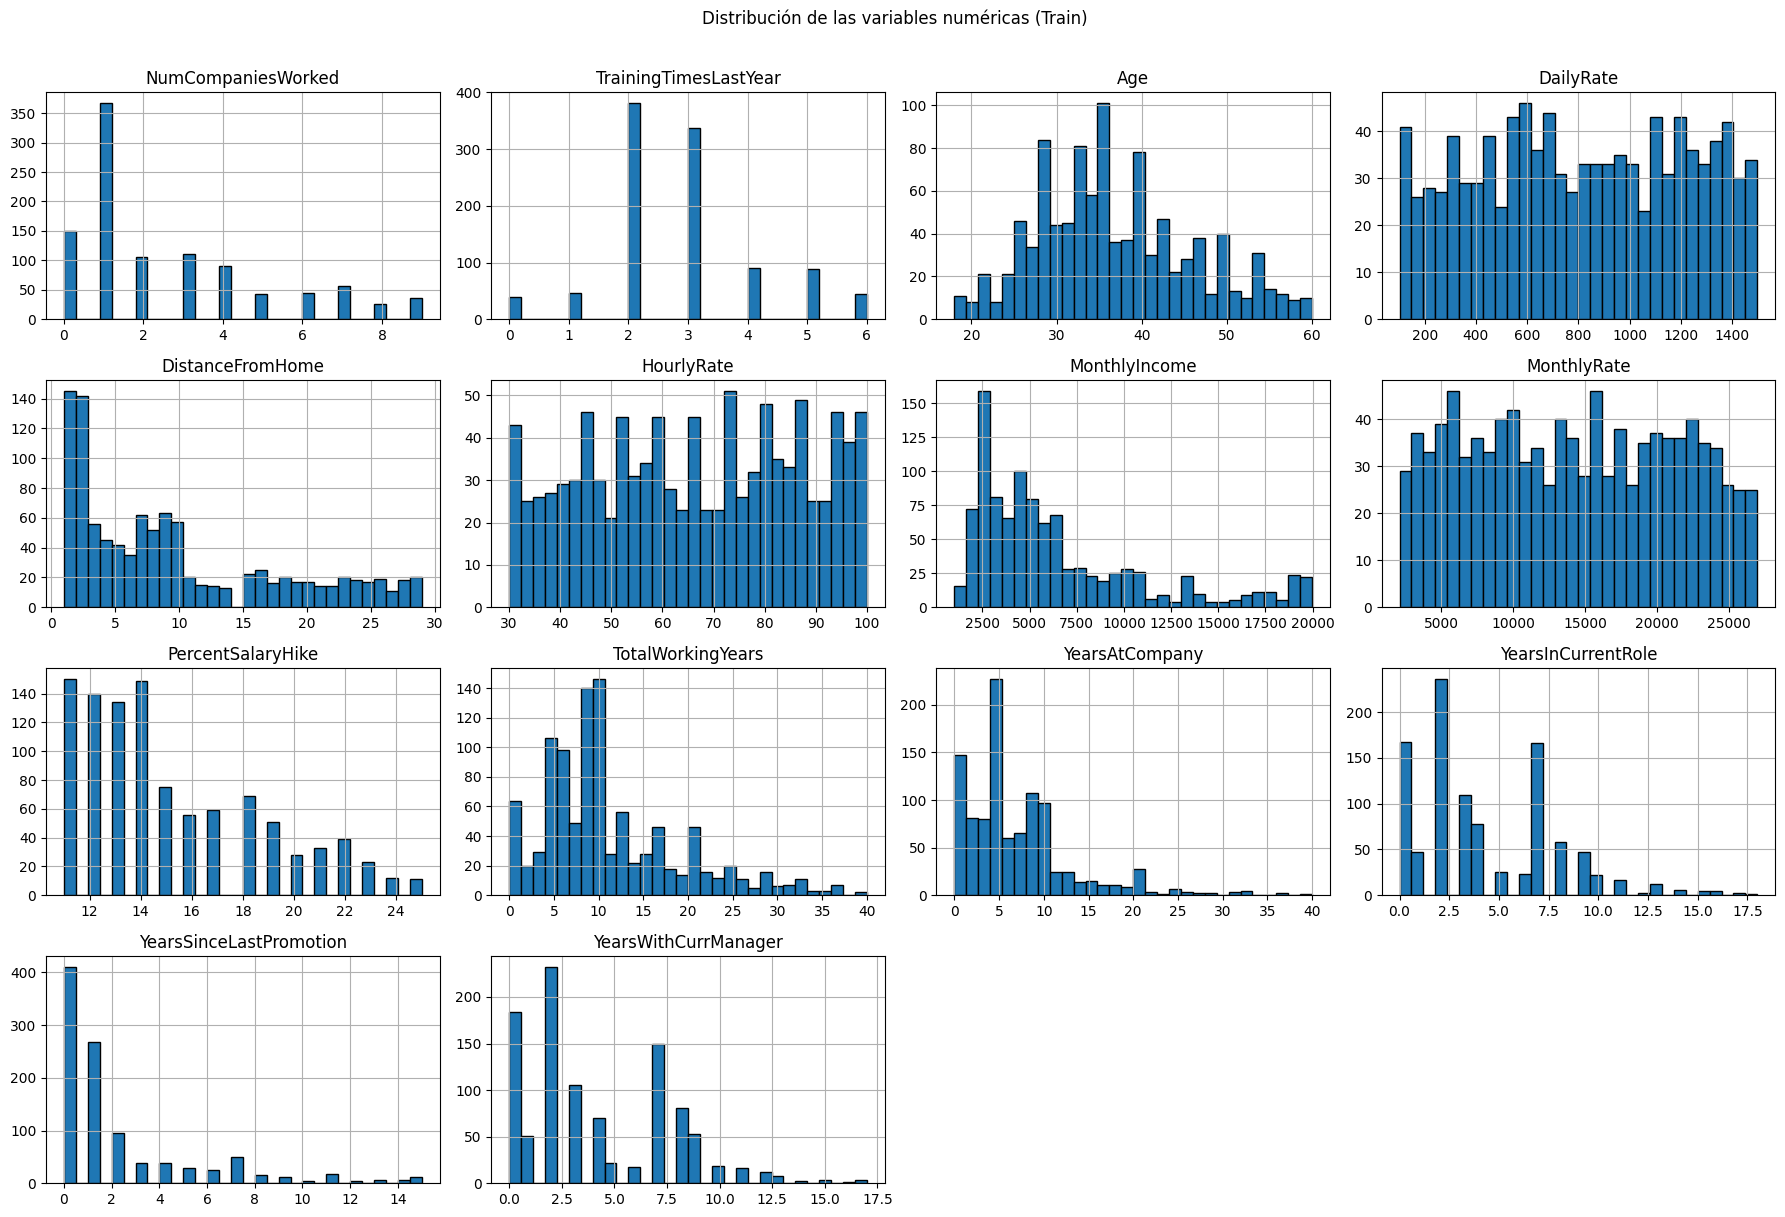

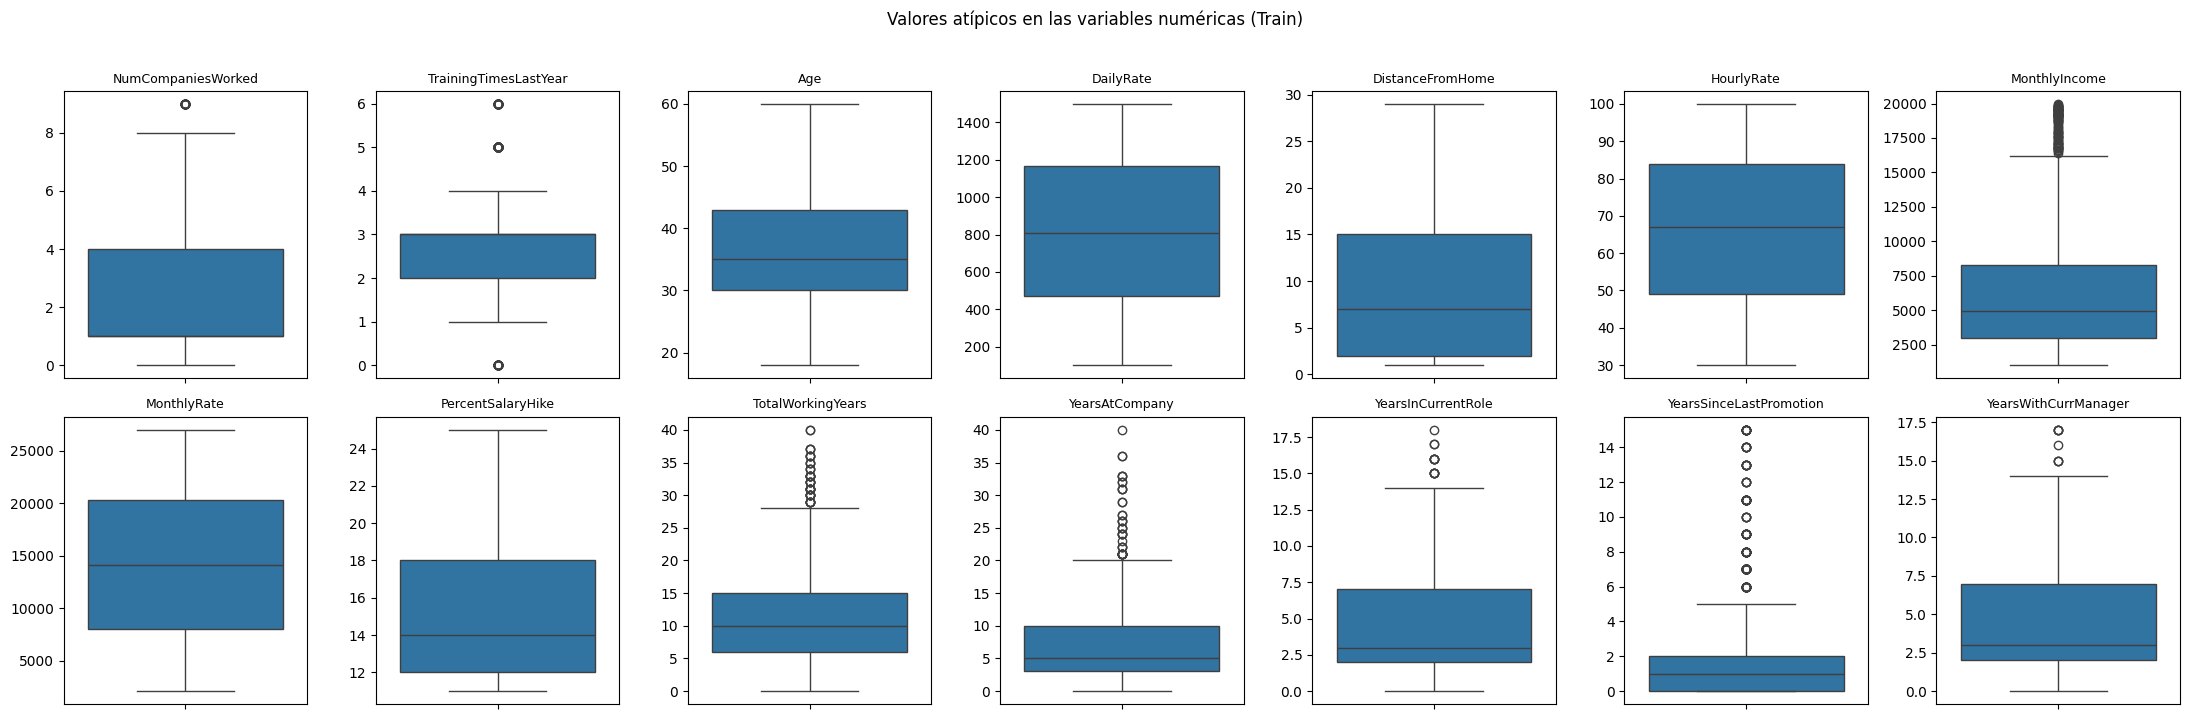

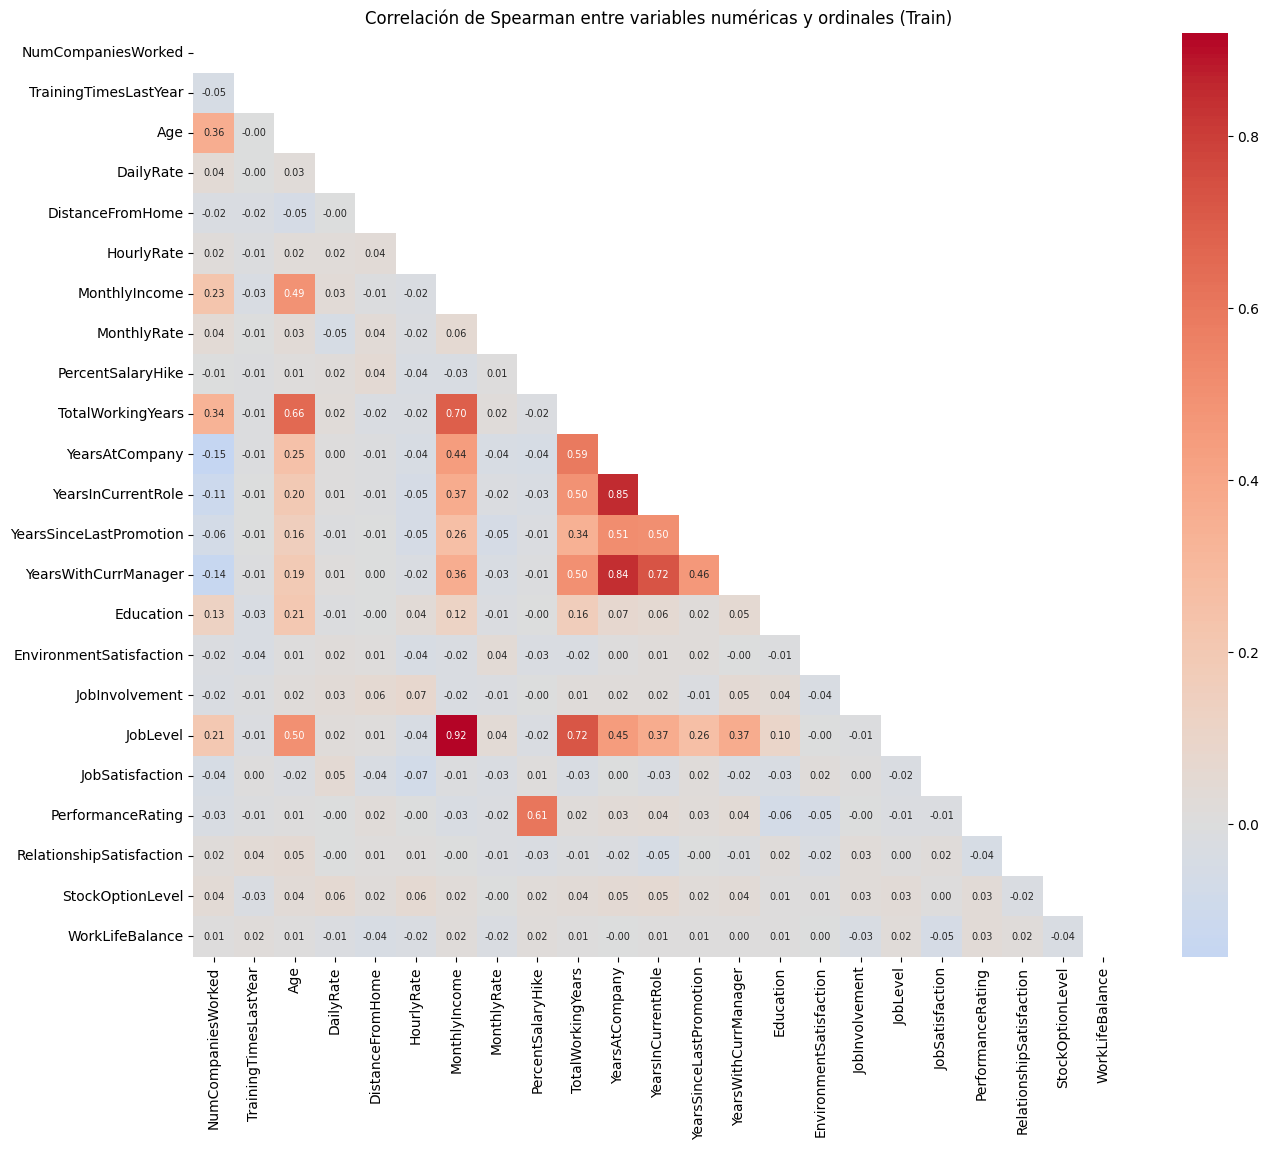

Pares con |correlación| > 0.7:
MonthlyIncome       JobLevel                0.92
YearsAtCompany      YearsInCurrentRole      0.85
                    YearsWithCurrManager    0.84
YearsInCurrentRole  YearsWithCurrManager    0.72
TotalWorkingYears   JobLevel                0.72
dtype: float64


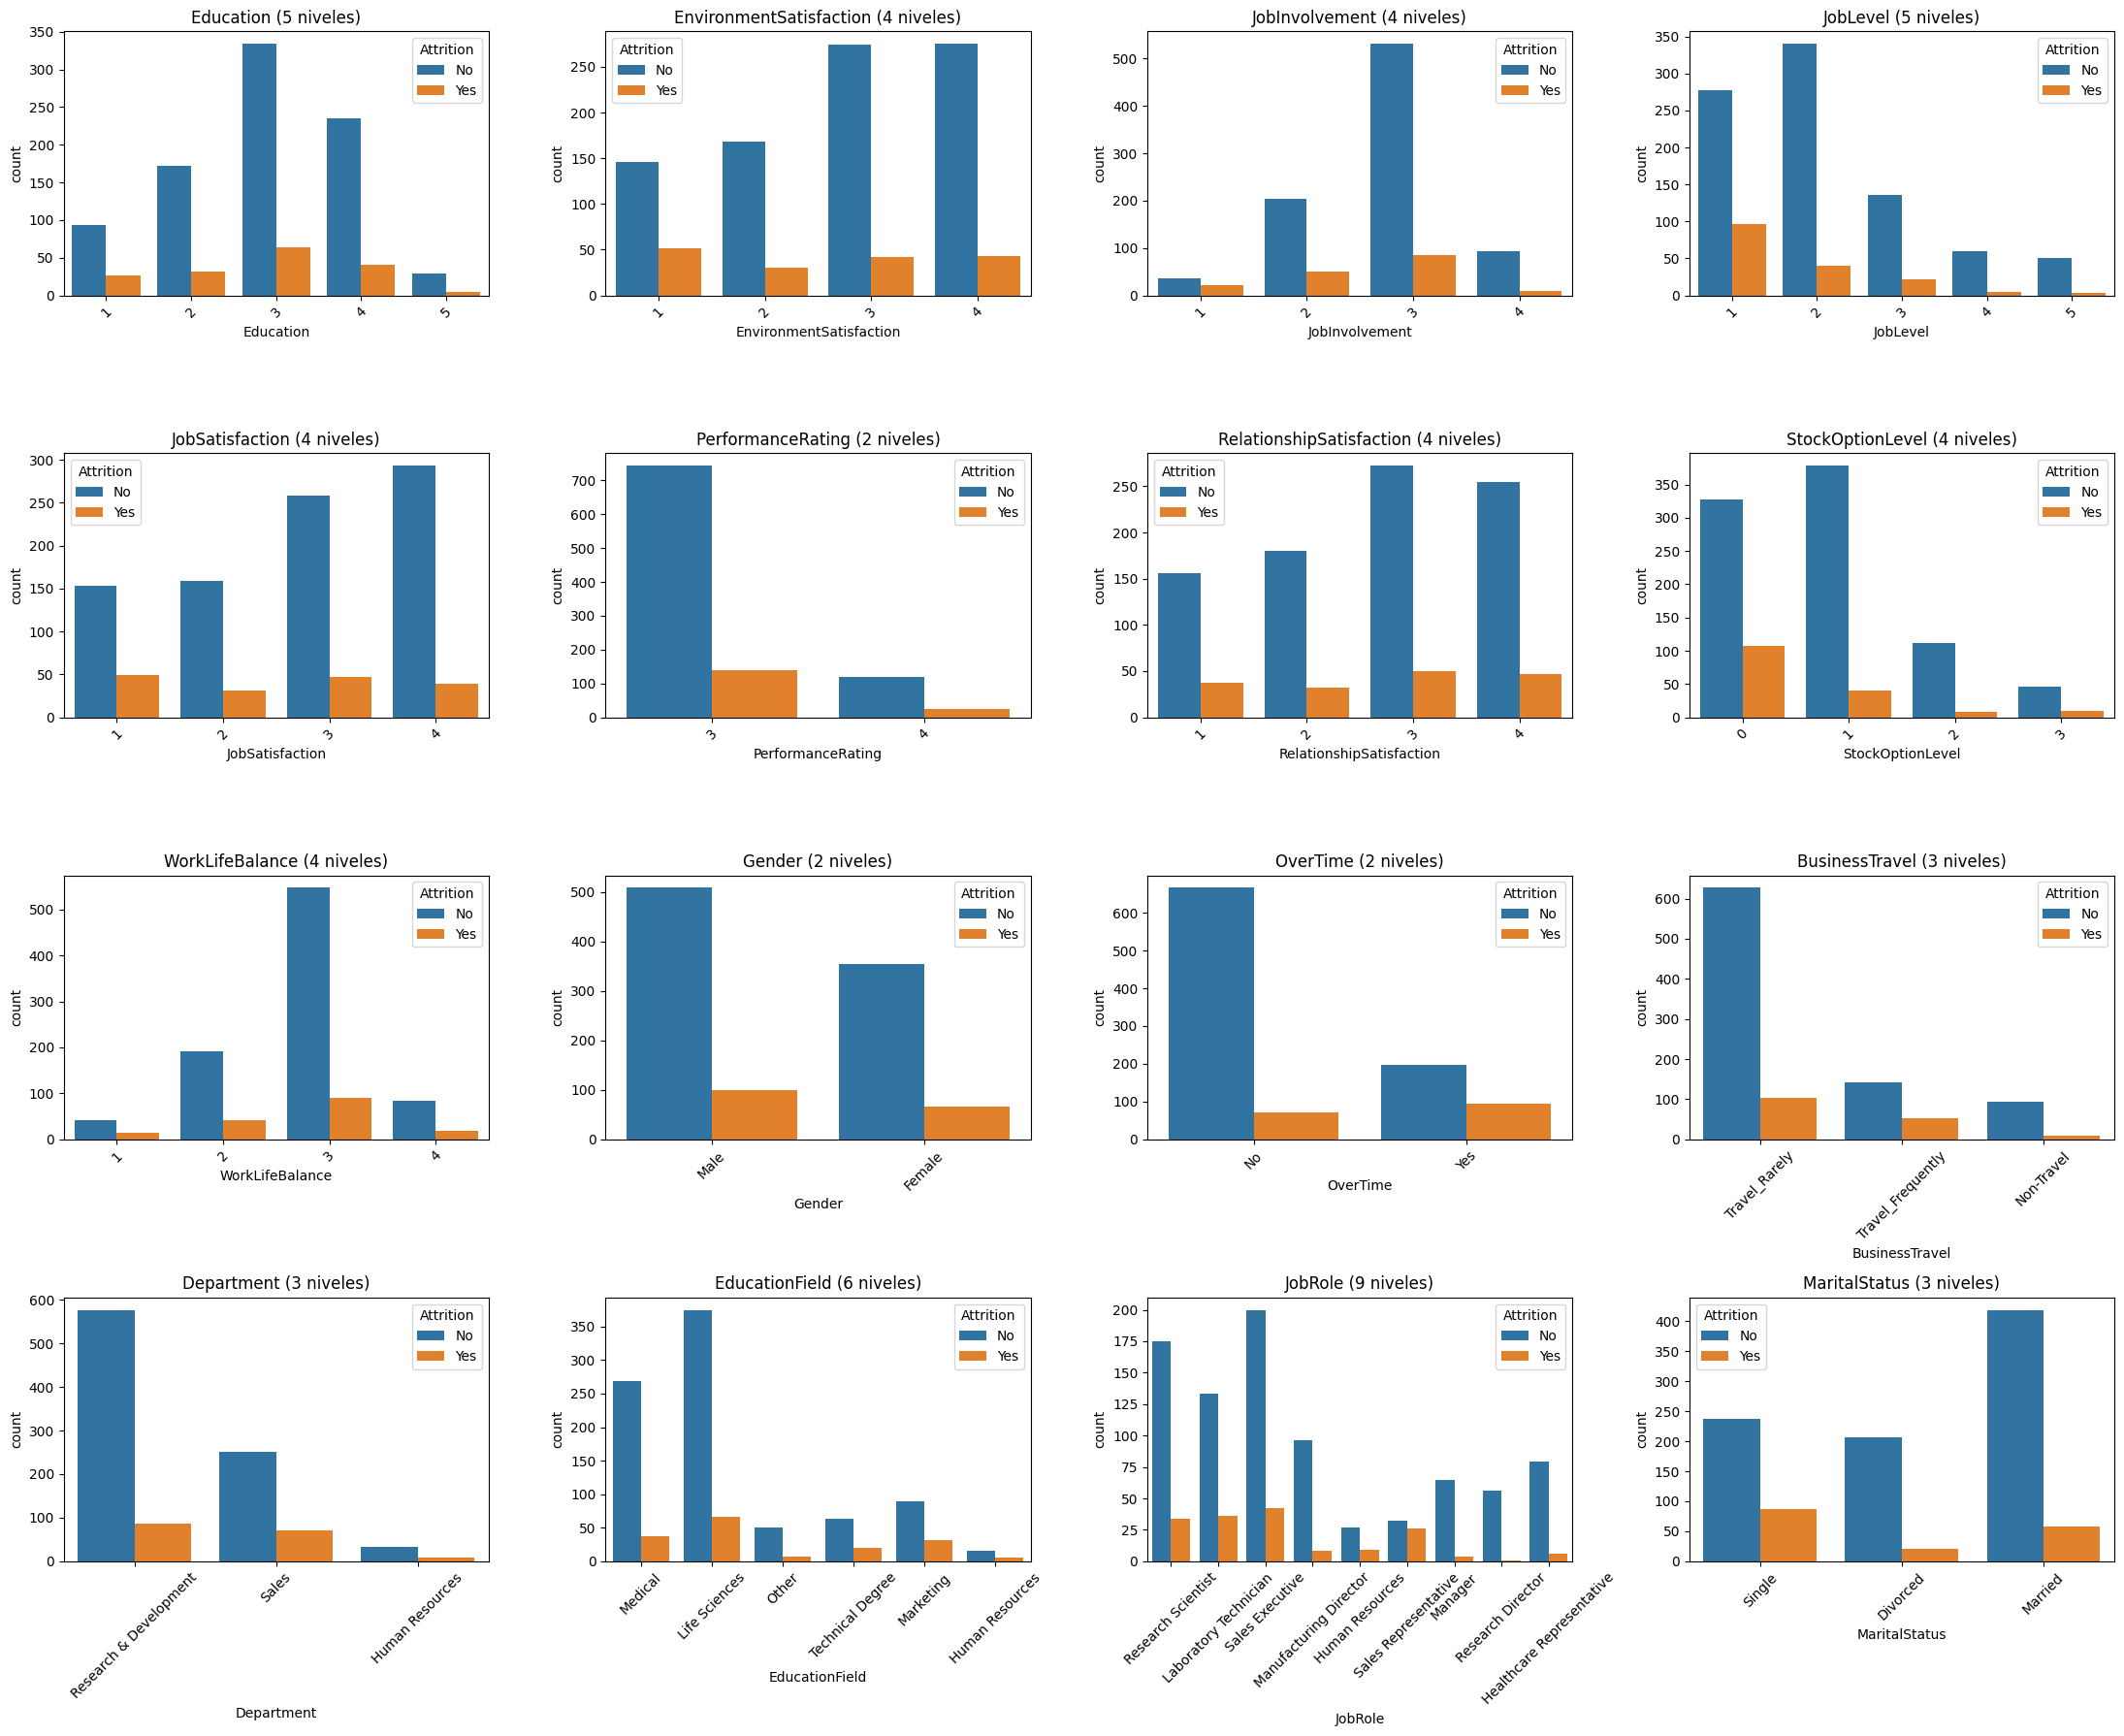


BusinessTravel (% por nivel):
BusinessTravel
Travel_Rarely        70.9
Travel_Frequently    19.0
Non-Travel           10.0
Name: proportion, dtype: float64

Department (% por nivel):
Department
Research & Development    64.5
Sales                     31.3
Human Resources            4.2
Name: proportion, dtype: float64

EducationField (% por nivel):
EducationField
Life Sciences       42.9
Medical             29.7
Marketing           11.8
Technical Degree     8.2
Other                5.5
Human Resources      1.9
Name: proportion, dtype: float64

JobRole (% por nivel):
JobRole
Sales Executive              23.5
Research Scientist           20.3
Laboratory Technician        16.4
Manufacturing Director       10.1
Healthcare Representative     8.3
Manager                       6.7
Sales Representative          5.6
Research Director             5.5
Human Resources               3.5
Name: proportion, dtype: float64

MaritalStatus (% por nivel):
MaritalStatus
Married     46.4
Single      31.6
D

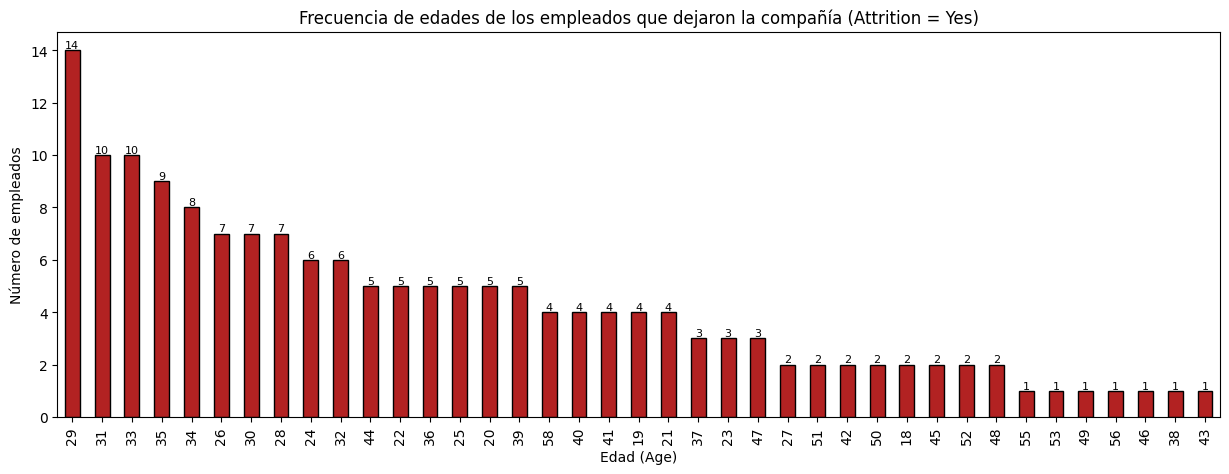

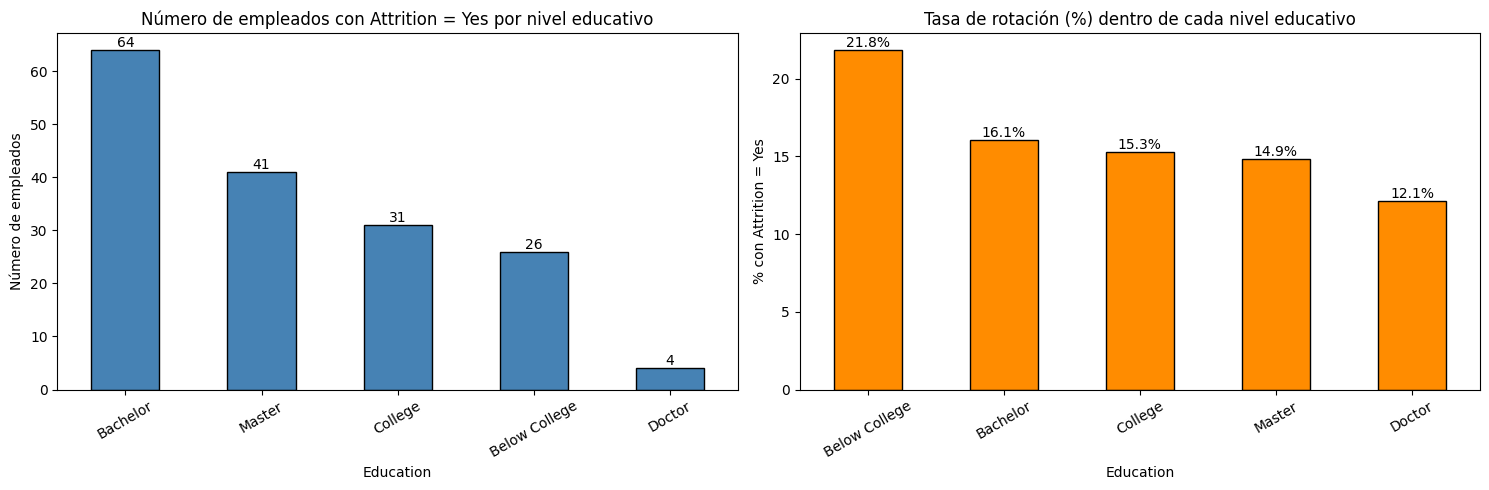

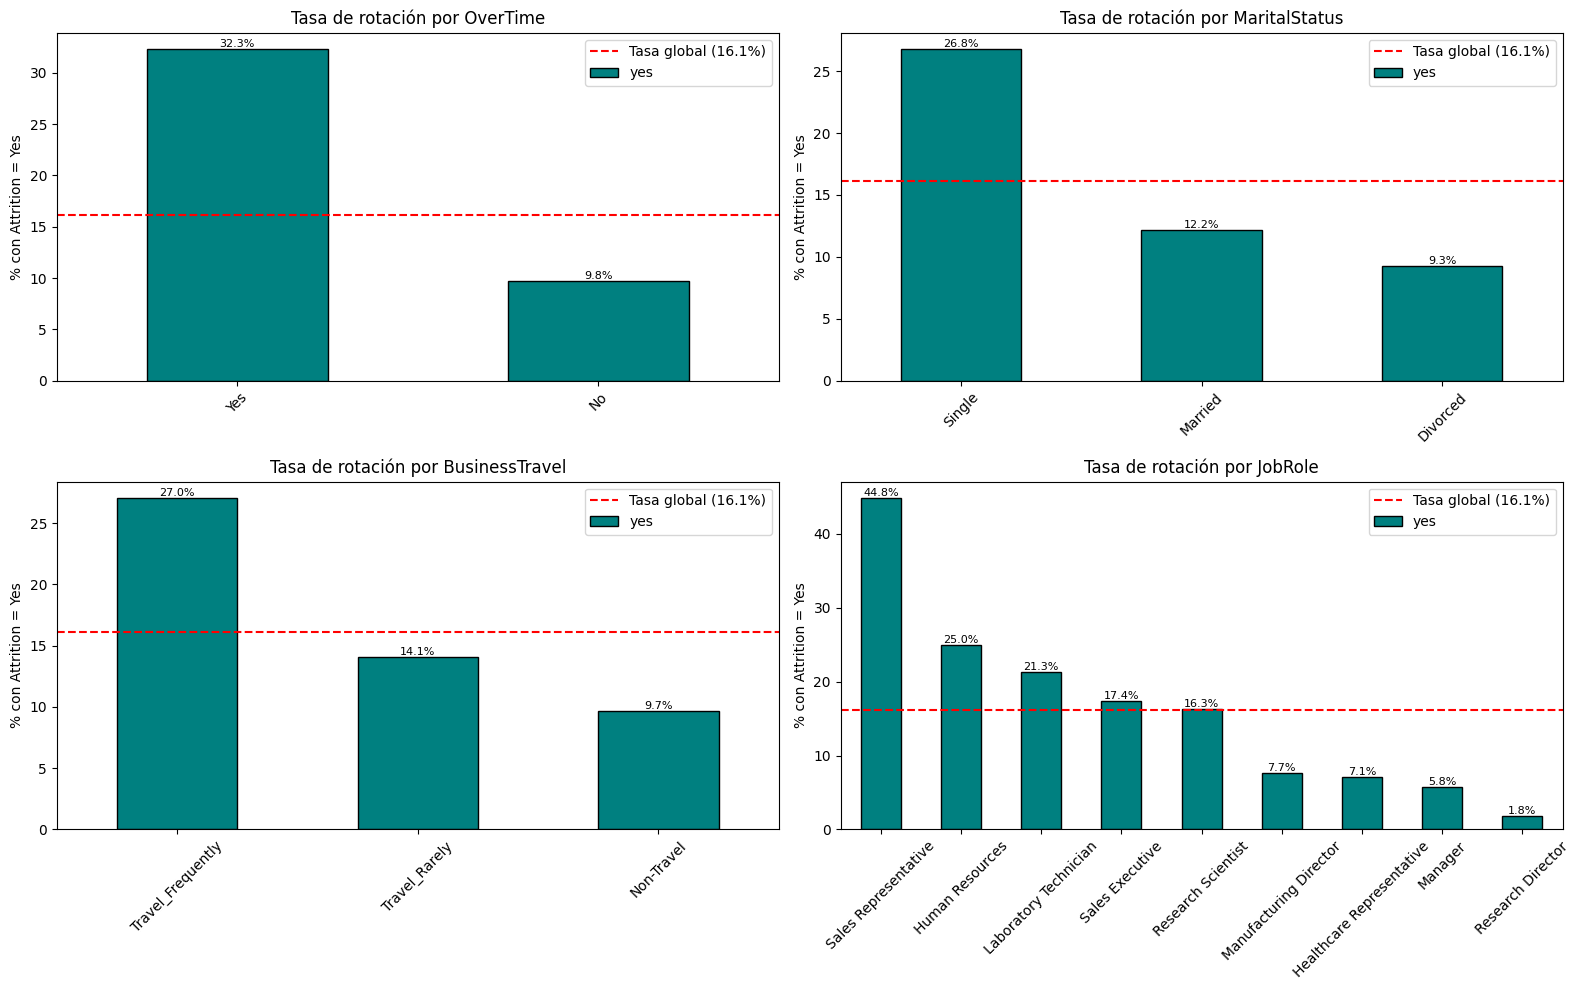

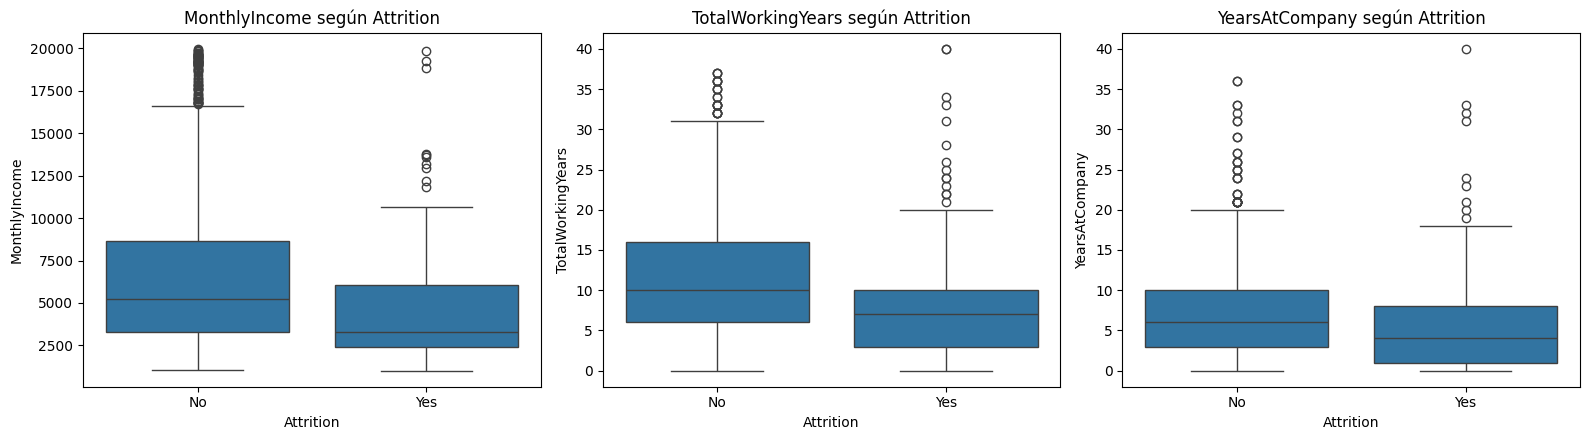

In [15]:

# ++++++++++ Inicia sección para agregar tu código ++++++++++++++++++++++++
# Incluye en esta sección todas las celdas que consideres necesarias.

# Incluye en esta sección todas las celdas que consideres necesarias.

# a) Análsis y gráficos

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Conjunto de entrenamiento con la variable de salida original (Yes/No)
eda = Xtrain.join(ytrain)
bin_in = ["Gender", "OverTime"]          # binarias de entrada

# a.1) Calidad de datos
print("Datos perdidos en Train:", eda.isnull().sum().sum())
print("Registros duplicados en Train:", eda.duplicated().sum())

# a.2) Numéricas: estadísticos descriptivos y sesgo
desc = eda[num_vars].describe().T
desc["sesgo"] = eda[num_vars].skew()
desc["valores_unicos"] = eda[num_vars].nunique()
display(desc.sort_values("sesgo", ascending=False).round(2))

# a.3) Numéricas: histogramas
eda[num_vars].hist(bins=30, figsize=(18, 12), layout=(4, 4), edgecolor="black")
plt.suptitle("Distribución de las variables numéricas (Train)", y=1.01)
plt.tight_layout()
plt.show()

# a.4) Numéricas: diagramas de caja (valores atípicos)
fig, axes = plt.subplots(2, 7, figsize=(22, 7))
for ax, c in zip(axes.ravel(), num_vars):
    sns.boxplot(y=eda[c], ax=ax)

    ax.set_title(c, fontsize=9)
    ax.set_ylabel("")
plt.suptitle("Valores atípicos en las variables numéricas (Train)", y=1.02)
plt.tight_layout()
plt.show()

# a.5) Correlaciones entre numéricas y ordinales
corr = eda[num_vars + ord_vars].corr(method="spearman")
plt.figure(figsize=(15, 12))
sns.heatmap(corr, mask=np.triu(np.ones_like(corr, dtype=bool)), annot=True,
            fmt=".2f", cmap="coolwarm", center=0, annot_kws={"size": 7})
plt.title("Correlación de Spearman entre variables numéricas y ordinales (Train)")
plt.show()

pares = corr.where(np.triu(np.ones_like(corr, dtype=bool), k=1)).stack()
print("Pares con |correlación| > 0.7:")
print(pares[pares.abs() > 0.7].sort_values(ascending=False).round(2))

# a.6) Ordinales, binarias y nominales: frecuencias por nivel y por Attrition
cat_vars = ord_vars + bin_in + nom_vars
fig, axes = plt.subplots(4, 4, figsize=(22, 18))
for ax, c in zip(axes.ravel(), cat_vars):
    sns.countplot(data=eda, x=c, hue="Attrition", ax=ax)
    ax.set_title(f"{c} ({eda[c].nunique()} niveles)")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

for c in nom_vars:
    print(f"\n{c} (% por nivel):")
    print((eda[c].value_counts(normalize=True) * 100).round(1))



# b) Gráfico age-attrition[yes]

edad_yes = eda.loc[eda["Attrition"] == "Yes", "Age"].value_counts()   # ordenado de mayor a menor

plt.figure(figsize=(15, 5))
ax = edad_yes.plot(kind="bar", color="firebrick", edgecolor="black")
ax.bar_label(ax.containers[0], fontsize=8)
plt.title("Frecuencia de edades de los empleados que dejaron la compañía (Attrition = Yes)")
plt.xlabel("Edad (Age)")
plt.ylabel("Número de empleados")
plt.show()


# c) Gráfico education-attrition[yes]

edu_labels = {1: "Below College", 2: "College", 3: "Bachelor", 4: "Master", 5: "Doctor"}
edu = eda.assign(EducationLabel=eda["Education"].map(edu_labels),
                 yes=(eda["Attrition"] == "Yes"))

conteo = edu.loc[edu["yes"], "EducationLabel"].value_counts()                           # frecuencia
tasa = (edu.groupby("EducationLabel")["yes"].mean() * 100).sort_values(ascending=False)  # porcentaje

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
conteo.plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="black")
axes[0].bar_label(axes[0].containers[0])
axes[0].set_title("Número de empleados con Attrition = Yes por nivel educativo")
axes[0].set_xlabel("Education"); axes[0].set_ylabel("Número de empleados")

tasa.plot(kind="bar", ax=axes[1], color="darkorange", edgecolor="black")
axes[1].bar_label(axes[1].containers[0], fmt="%.1f%%")
axes[1].set_title("Tasa de rotación (%) dentro de cada nivel educativo")

axes[1].set_xlabel("Education"); axes[1].set_ylabel("% con Attrition = Yes")

for ax in axes:
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()


# d) [gráfico opcional]

eda_y = eda.assign(yes=(eda["Attrition"] == "Yes"))
tasa_global = eda_y["yes"].mean() * 100

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, c in zip(axes.ravel(), ["OverTime", "MaritalStatus", "BusinessTravel", "JobRole"]):
    t = (eda_y.groupby(c)["yes"].mean() * 100).sort_values(ascending=False)
    t.plot(kind="bar", ax=ax, color="teal", edgecolor="black")
    ax.axhline(tasa_global, color="red", linestyle="--", label=f"Tasa global ({tasa_global:.1f}%)")
    ax.bar_label(ax.containers[0], fmt="%.1f%%", fontsize=8)
    ax.set_title(f"Tasa de rotación por {c}")
    ax.set_ylabel("% con Attrition = Yes"); ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=45)
    ax.legend()
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, c in zip(axes, ["MonthlyIncome", "TotalWorkingYears", "YearsAtCompany"]):
    sns.boxplot(data=eda, x="Attrition", y=c, ax=ax)
    ax.set_title(f"{c} según Attrition")
plt.tight_layout()
plt.show()


# ++++++++++ Termina sección para agregar tu código ++++++++++++++++++++++++



**e) ¿Qué es más costoso, los Falsos Negativos o los Falsos Positivos?**

++++++++ Inicia la sección de agregar texto: ++++++++++++


**Son más costosos los Falsos Negativos.**

- **Falso Negativo (FN):** el modelo predice que el empleado se queda
  (clase 0), pero en realidad renuncia (clase 1). La empresa no interviene y
  asume el costo completo de la salida: reclutamiento, selección y
  capacitación del reemplazo, pérdida de conocimiento y de relaciones con
  clientes, menor productividad durante la curva de aprendizaje y sobrecarga
  del equipo que permanece. En la literatura de recursos humanos este costo
  suele estimarse como una fracción considerable del salario anual del
  puesto, mayor cuanto más especializado es.

- **Falso Positivo (FP):** el modelo predice que el empleado renunciará
  (clase 1), pero en realidad se queda (clase 0). Es una falsa alarma: la
  empresa invierte en una acción de retención innecesaria, como una
  entrevista, un plan de desarrollo o un ajuste salarial.

Para una empresa como IBM, cuyo valor depende de personal altamente
calificado,



++++++++ Termina la sección de agregar texto: ++++++++++++

# **Ejercicio 7:**

#### **Utiliza las clases Pipeline y ColumnTransformer de Sklearn para definir las transformaciones que deberás aplicar a cada variable y de acuerdo a su tipo considerado previamente.**



In [18]:
# ++++++++++ Inicia sección para agregar tu código ++++++++++++++++++++++++


# ++++++++++ Inicia sección para agregar tu código ++++++++++++++++++++++++

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import PowerTransformer, MinMaxScaler, OrdinalEncoder, OneHotEncoder

# NUMÉRICAS: imputación con mediana + Yeo-Johnson (corrige sesgo y estandariza)
numericas_pipeline = Pipeline(steps=[
    ("imputar", SimpleImputer(strategy="median")),
    ("potencia", PowerTransformer(method="yeo-johnson", standardize=True))
])
numericas_pipeline_nombres = ["NumCompaniesWorked", "TrainingTimesLastYear", "Age", "DailyRate",
                              "DistanceFromHome", "HourlyRate", "MonthlyIncome", "MonthlyRate",
                              "PercentSalaryHike", "TotalWorkingYears", "YearsAtCompany",
                              "YearsInCurrentRole", "YearsSinceLastPromotion", "YearsWithCurrManager"]

# ORDINALES: imputación con moda + escalamiento a [0, 1] (ya vienen como enteros ordenados)
catOrd_pipeline = Pipeline(steps=[
    ("imputar", SimpleImputer(strategy="most_frequent")),
    ("escalar", MinMaxScaler())
])
catOrd_pipeline_nombres = ["Education", "EnvironmentSatisfaction", "JobInvolvement", "JobLevel",
                           "JobSatisfaction", "PerformanceRating", "RelationshipSatisfaction",
                           "StockOptionLevel", "WorkLifeBalance"]

# BINARIAS: imputación con moda + codificación 0/1
catBin_pipeline = Pipeline(steps=[
    ("imputar", SimpleImputer(strategy="most_frequent")),
    ("codificar", OrdinalEncoder())
])
catBin_pipeline_nombres = ["Gender", "OverTime"]      # Attrition es la salida, no entra aquí


# NOMINALES: imputación con moda + One-Hot Encoding
catNom_pipeline = Pipeline(steps=[
    ("imputar", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])
catNom_pipeline_nombres = ["BusinessTravel", "Department", "EducationField", "JobRole", "MaritalStatus"]


columnasTransformer = ColumnTransformer(transformers=[
    ("num",    numericas_pipeline, numericas_pipeline_nombres),
    ("catOrd", catOrd_pipeline,    catOrd_pipeline_nombres),
    ("catBin", catBin_pipeline,    catBin_pipeline_nombres),
    ("catNom", catNom_pipeline,    catNom_pipeline_nombres)
], remainder="drop")


# ++++++++++ Termina sección para agregar tu código ++++++++++++++++++++++++



# ++++++++++ Termina sección para agregar tu código ++++++++++++++++++++++++

In [21]:
#Verificación final#
Xprueba = columnasTransformer.fit_transform(Xtrain)
print("Dimensión de Train transformado:", Xprueba.shape)
print("Datos perdidos tras transformar:", np.isnan(Xprueba).sum())

Dimensión de Train transformado: (1029, 49)
Datos perdidos tras transformar: 0


**Justificación de las transformaciones**

**a) Datos perdidos.** El conjunto no tiene datos perdidos, pero se incluye un
`SimpleImputer` como primer paso de cada pipeline para que el modelo pueda
procesar datos nuevos incompletos sin fallar. Para las numéricas se usa la
**mediana**, robusta ante el sesgo y los valores atípicos observados; para
las ordinales, binarias y nominales se usa la **moda**, que es la única
medida de tendencia central válida para categorías.

**b) Numéricas.** Se aplica `PowerTransformer` con el método **Yeo-Johnson**,
porque varias variables tienen sesgo positivo marcado y valores atípicos, y
este método admite ceros (frecuentes en las variables de años), a diferencia
de Box-Cox. Con `standardize=True` las variables quedan además con media 0 y
desviación estándar 1, lo que resuelve la diferencia de escalas y favorece a
los modelos sensibles a ella (regresión logística, SVM, kNN, redes
neuronales).

**c) Ordinales.** Ya están codificadas como enteros que respetan el orden de
sus niveles, por lo que no requieren recodificación. Solo se aplica
`MinMaxScaler` para llevarlas al rango [0, 1], comparable con las binarias y
las columnas One-Hot, conservando el orden y la distancia entre niveles.

**d) Binarias.** `Gender` y `OverTime` son texto con dos niveles. Se
codifican como 0/1 con `OrdinalEncoder`; al haber solo dos categorías, una
sola columna contiene toda la información y no se introduce un orden
artificial.

**e) Nominales.** No tienen orden natural, por lo que asignarles enteros
introduciría una relación de orden inexistente. Se aplica `OneHotEncoder`,
viable porque tienen pocos niveles (de 3 a 9) y solo se generan 24 columnas.
Se usa `handle_unknown="ignore"` para que un nivel no visto en entrenamiento
no provoque error en validación o prueba.


Todas las transformaciones se integran en un `ColumnTransformer` que se
ajustará únicamente con el conjunto de entrenamiento dentro del pipeline de
cada modelo, evitando el filtrado de información.

* #### **Vamos a utilizar validación cruzada, por lo que decidimos para esta actividad reagrupar los conjuntos de entrenamiento y validación en un solo DataFrame.**

* #### **Al resultado obtenido los llamaremos Xtv y ytv.**


In [22]:
Xtv = pd.concat([Xtrain, Xval], axis=0)
ytv = pd.concat([ytrainT, yvalT], axis=0)


print("Dimensión del conjunto Train+Val:")
print(Xtv.shape)
print(ytv.shape)

Dimensión del conjunto Train+Val:
(1249, 30)
(1249, 1)


# **Ejercicio 8:**

#### **Entrenamiento y ajuste de hiperparámetros**

#### **a) Busca los mejores hiperparámetros para cada modelo, de manera que no estén subentrenados con respecto a la métrica de la exactitud (accuracy).**

#### **b) Incluye tus comentarios sobre el resultado obtenido.**



#### **NOTA-1: En dado caso, cuando mucho uno de los modelos podría quedar subentrenado.**

#### **NOTA-2: Por el momento estamos usando la métrica de la exactitud (accuracy). El objetivo de esta actividad es que sepas entrenar modelos sin que resulten subentrenados o sobreentrenados, independientemente de la métrica a considerar. En próximas semanas seguiremos con el estudio de las otras métricas para abordar de mejor manera los problemas y obtener mejores resultados.**

En relación a la variante de Validación Cruzada "RepeatedStratifiedKFold" utilizada en este ejercicio, puedes consultar la siguiente liga:

  https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RepeatedStratifiedKFold.html


In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, RepeatedStratifiedKFold

cv1 = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=7)
Cs = [0.01, 0.03, 0.1, 0.3, 1, 3, 10]

busquedas = {
    "LASSO": (LogisticRegression(penalty="l1", solver="liblinear", max_iter=2000, random_state=1),
              {"m__C": Cs}),
    "RIDGE": (LogisticRegression(penalty="l2", solver="lbfgs", max_iter=2000, random_state=1),
              {"m__C": Cs}),
    "EN":    (LogisticRegression(penalty="elasticnet", solver="saga", max_iter=5000, random_state=1),
              {"m__C": Cs, "m__l1_ratio": [0.25, 0.5, 0.75]}),
    "KNN":   (KNeighborsClassifier(),
              {"m__n_neighbors": [5, 9, 13, 17, 21, 25, 31],
               "m__weights": ["uniform", "distance"],
               "m__p": [1, 2]}),
}

print("Baseline (clase mayoritaria) en Train+Val: %.3f" % (1 - np.ravel(ytv).mean()))
for nombre, (modelo, grid) in busquedas.items():
    pipe = Pipeline(steps=[("ct", columnasTransformer), ("m", modelo)])
    gs = GridSearchCV(pipe, grid, scoring="accuracy", cv=cv1, return_train_score=True, n_jobs=-1)
    gs.fit(Xtv, np.ravel(ytv))
    i = gs.best_index_
    print(">> %-6s mejor: %s | val: %.3f | train: %.3f" %
          (nombre, gs.best_params_, gs.best_score_, gs.cv_results_["mean_train_score"][i]))

Baseline (clase mayoritaria) en Train+Val: 0.839
>> LASSO  mejor: {'m__C': 1} | val: 0.887 | train: 0.907
>> RIDGE  mejor: {'m__C': 0.3} | val: 0.888 | train: 0.903
>> EN     mejor: {'m__C': 1, 'm__l1_ratio': 0.5} | val: 0.888 | train: 0.906
>> KNN    mejor: {'m__n_neighbors': 17, 'm__p': 1, 'm__weights': 'distance'} | val: 0.851 | train: 1.000


>> LR 0.885 (0.015)
>> LASSO 0.885 (0.013)
>> RIDGE 0.879 (0.012)
>> EN 0.887 (0.014)
>> KNN 0.845 (0.008)


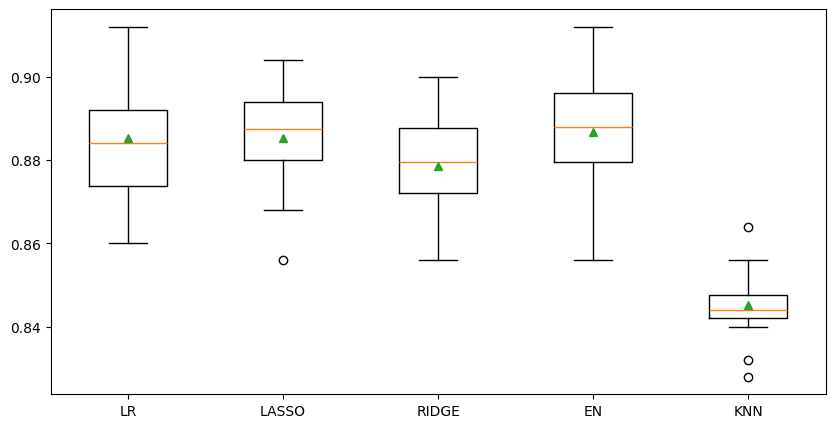

In [24]:
# 8a) Ajuste de hiperparámetros.
#     En cada modelo que utilcemos a continuación, utiliza la semilla "random_state=1"
#     indicada, para obtener la repetibilidad de los resultados en la manera de lo
#     posible. Es decir, este argumento y valor no deberás modificarlo.

# ++++++++++ Inicia sección para agregar tu código ++++++++++++++++++++++++


# ++++++++++ Inicia sección para agregar tu código ++++++++++++++++++++++++


def mis_modelos():
  modelos, nombres = list(), list()

  # LR - Regresión Logística sin regularización:
  modelos.append(LogisticRegression(penalty=None,  # Este valor de "None" no lo debes cambiar. Define al modelo sin regularización.
                                    solver='lbfgs',
                                    max_iter=2000,
                                    random_state=1))
  nombres.append('LR')



  # Lasso - Regresión Logística con regularización L1:
  modelos.append(LogisticRegression(penalty='l1',
                                    solver='liblinear',
                                    C=0.3,
                                    max_iter=2000,
                                    random_state=1))
  nombres.append('LASSO')



  # Ridge - Regresión Logística con regularización L2:
  modelos.append(LogisticRegression(penalty='l2',
                                    solver='lbfgs',
                                    C=0.1,
                                    max_iter=2000,
                                    random_state=1))
  nombres.append('RIDGE')




  # Elastic_Net - - Regresión Logística con regularización L1 y L2:
  modelos.append(LogisticRegression(penalty='elasticnet',
                                    solver='saga',
                                    l1_ratio=0.5,
                                    C=0.3,
                                    max_iter=5000,
                                    random_state=1))
  nombres.append('EN')



  # KNN - K-Vecinos más cercanos:
  modelos.append(KNeighborsClassifier(n_neighbors=17,
                                      weights='distance',
                                      p=2
                                      ))
  nombres.append('KNN')

  return modelos, nombres




# ++++++++++ Termina sección para agregar tu código ++++++++++++++++++++++++



# ++++++++++ Termina sección para agregar tu código ++++++++++++++++++++++++


# Pasamos al entrenamiento de los modelos.
# Hay obviamente varias maneras de llevar a cabo el entrenamiento,
# pero por el momento supongamos que lo hacemos de la manera siguiente:

modelos, nombres = mis_modelos()  # accesando los modelos.
resultados = list()    # para guardar los resultados en esta lista.

# Iterando y entrenando sobre cada modelo:
for i in range(len(modelos)):

  pipeline = Pipeline(steps=[('ct',columnasTransformer),('m',modelos[i])])   # Conjuntamos Transformaciones y modelos en un Pipeline.

  cv1 = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=7)     # Aplicando una de las variantes de Validación Cruzada.

  scores = cross_val_score(pipeline, Xtv, np.ravel(ytv), scoring='accuracy', cv=cv1)   # Entrenando y generando los resultados con la exactitud (accuracy).


  resultados.append(scores)    # Guardamos los resultados en la lista.
  print('>> %s %.3f (%.3f)' % (nombres[i], np.nanmean(scores), np.nanstd(scores)))  # Desplegando los promedios de cada modelo.


plt.figure(figsize=(10,5))
plt.boxplot(resultados, tick_labels=nombres, showmeans=True)   # Gráficos de caja para una comparación visual de los resultados.
plt.show()


**8b) Comentarios sobre los resultados y modelos obtenidos. En particular indica cuál consideras el mejor modelo. ¿Alguno quedó subentrenado y ya no se pudo mejorar su desempeño?**

++++++++ Inicia la sección de agregar texto: ++++++++++++


**Resultados.** El umbral a superar es la exactitud del modelo ingenuo, que
predice siempre la clase mayoritaria (No): aproximadamente 0.839. Con
validación cruzada estratificada repetida (5 particiones, 3 repeticiones) se
obtuvo:

| Modelo | Exactitud media | Desv. estándar | Diferencia vs. umbral |
|--------|-----------------|----------------|-----------------------|
| LR     | 0.885           | 0.015          | +0.046                |
| LASSO  | 0.885           | 0.013          | +0.046                |
| RIDGE  | 0.879           | 0.012          | +0.040                |
| EN     | 0.887           | 0.014          | +0.048                |
| KNN    | 0.845           | 0.008          | +0.006                |




**Comentarios.** Los cuatro modelos de regresión logística superan
claramente el umbral, entre 4 y 5 puntos porcentuales, es decir, por unas
tres desviaciones estándar, por lo que no están subentrenados. Su desempeño
es prácticamente equivalente: la diferencia entre el mejor (EN, 0.887) y el
menor de ellos (RIDGE, 0.879) es de 0.008, inferior a la desviación estándar
de cualquiera de los cuatro, de modo que no puede considerarse una
diferencia significativa.

La regularización casi no modifica el resultado respecto al modelo sin
regularizar (LR, 0.885). Esto es razonable porque se tienen 1249 registros
frente a 49 variables transformadas, una proporción suficiente para que el
modelo sin penalización no se sobreajuste de forma apreciable. RIDGE obtiene
la media más baja de los cuatro, lo que sugiere que la penalización usada
(C = 0.1) es algo más fuerte de lo necesario, aunque también es el de menor
variabilidad entre los modelos logísticos.

**Mejor modelo.** Se considera mejor la regresión logística con
regularización **Elastic Net (EN)**, con la exactitud media más alta (0.887)
y una variabilidad comparable a la de los demás (0.014). Al combinar las

penalizaciones L1 y L2 conserva la capacidad de L1 de anular coeficientes de
factores poco relevantes y la estabilidad de L2 ante factores
correlacionados, como los detectados en el análisis exploratorio (JobLevel y
MonthlyIncome, y las variables de antigüedad). Cabe reconocer que su ventaja
sobre LR y LASSO es de apenas 0.002, por lo que cualquiera de los tres sería
una elección defendible.

**Subentrenamiento.** El modelo **KNN** es el único que puede considerarse
subentrenado. Su exactitud (0.845) supera el umbral por solo 0.006, menos de
una desviación estándar, por lo que en la práctica su desempeño es
indistinguible del modelo ingenuo. Se probaron distintos valores del número
de vecinos, de la ponderación (uniforme y por distancia) y de la métrica de
distancia (Manhattan y Euclidiana) sin lograr una mejora relevante. Esto se
explica por tres razones: (1) trabaja en un espacio de 49 dimensiones, donde
las distancias entre puntos pierden capacidad de discriminación (maldición
de la dimensionalidad); (2) da el mismo peso a todas las variables, incluidas
las poco informativas y las columnas binarias del One-Hot; y (3) con una
clase minoritaria de alrededor de 16 %, la mayoría de los vecinos de casi
cualquier punto pertenece a la clase mayoritaria, por lo que el modelo tiende
a predecir "No" casi siempre. Esto coincide con lo anticipado en la NOTA-1
del ejercicio.


++++++++ Termina la sección de agregar texto: ++++++++++++


# **Ejercicio 9:**

* #### **Utiliza el mejor modelo encontrado en el paso anterior, los datos Xtv, ytv, y realiza ahora una búsqueda de malla con validación cruzada para tratar de mejorar el desempeño de este modelo.**

* #### **Sigue utilizando la métrica de la exactitud (accuracy).**

* #### **Verifica además que el modelo no esté subentrenado o sobreentrenado.**

* #### **Llama "resultado_malla" al mejor modelo ajustado.**




* **NOTA-1: Para esta actividad diremos que el modelo no está sobreentrenado si la diferencia entre Train y Validation es menor al 3%.**


* **NOTA-2: Puedes utilizar GridSearchCV, o bien, RandomizedSearchCV. La documentación la puedes consultar en las siguientes ligas:**

https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html

https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html


In [26]:
# +++++++++ Inicia sección para incluir tu código ++++++++++++++++++++++++




from sklearn.model_selection import GridSearchCV

# Mejor modelo del ejercicio anterior: Regresión Logística con Elastic Net
modelo_en = LogisticRegression(penalty='elasticnet', solver='saga', max_iter=5000, random_state=1)

pipeline_en = Pipeline(steps=[('ct', columnasTransformer), ('m', modelo_en)])

# Malla de hiperparámetros: intensidad de la regularización (C) y mezcla L1/L2 (l1_ratio)
malla = {
    'm__C': [0.05, 0.1, 0.2, 0.3, 0.5, 1.0, 2.0],
    'm__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
}

cv_malla = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=7)

busqueda = GridSearchCV(estimator=pipeline_en,
                        param_grid=malla,
                        scoring='accuracy',
                        cv=cv_malla,
                        return_train_score=True,   # necesario para comparar Train vs Validation
                        n_jobs=-1)

resultado_malla = busqueda.fit(Xtv, np.ravel(ytv))




# +++++++++ Termina sección para incluir tu código ++++++++++++++++++++++++


print("Desempeño del mejor modelo con la métrica de Exactitud (Accuracy)")
print("-"*65)
print("Mejor modelo: %f usando los hiperparámetros %s" % (resultado_malla.best_score_, resultado_malla.best_params_))
print('Promedios Train mean(std): %.2f%% (%.4f%%)' % (100*np.nanmean(resultado_malla.cv_results_['mean_train_score']),
                                                 100*np.nanmean(resultado_malla.cv_results_['std_train_score'])))
print('Promedios Val mean(std): %.2f%% (%.4f%%)' % (100*resultado_malla.cv_results_['mean_test_score'].mean(),
                                               100*resultado_malla.cv_results_['std_test_score'].mean()))


Desempeño del mejor modelo con la métrica de Exactitud (Accuracy)
-----------------------------------------------------------------
Mejor modelo: 0.888978 usando los hiperparámetros {'m__C': 0.5, 'm__l1_ratio': 0.3}
Promedios Train mean(std): 89.25% (0.4595%)
Promedios Val mean(std): 87.87% (1.2649%)


In [27]:
#Verificación de subentrenamiento y sobreentrenamiento (celda aparte). La salida del profesor da promedios de toda la malla; esta celda revisa específicamente el mejor modelo, que es lo que pide el enunciado:#
i = resultado_malla.best_index_
train_mejor = resultado_malla.cv_results_['mean_train_score'][i]
val_mejor = resultado_malla.cv_results_['mean_test_score'][i]
baseline = 1 - np.ravel(ytv).mean()

print("Mejor modelo de la malla")
print("-" * 40)
print("Exactitud Train:      %.2f%%" % (100 * train_mejor))
print("Exactitud Validation: %.2f%%" % (100 * val_mejor))
print("Diferencia Train-Val: %.2f%%  -> %s" % (100 * (train_mejor - val_mejor),
      "sin sobreentrenamiento (< 3%)" if (train_mejor - val_mejor) < 0.03 else "SOBREENTRENADO"))
print("Baseline:             %.2f%%  -> %s" % (100 * baseline,
      "sin subentrenamiento" if val_mejor > baseline else "SUBENTRENADO"))

Mejor modelo de la malla
----------------------------------------
Exactitud Train:      90.47%
Exactitud Validation: 88.90%
Diferencia Train-Val: 1.57%  -> sin sobreentrenamiento (< 3%)
Baseline:             83.91%  -> sin subentrenamiento


# **Ejercicio 10:**

#### **Finalmente, usando el conjunto de prueba (Test) responde los siguientes incisos:**

#### **a) Obtener el desempeño final del mejor modelo con el reporte de métricas classification_report() de Sklearn.**

#### **b) Obtener la matriz de confusión del mejor modelo.**

#### **c) Indica como se leen o interpretan los valores VP, VN, FP, FN obtenidos y de acuerdo al contexto del problema.**

#### **d) Realiza un análisis de importancia de los factores o características e incluye tus comentarios.**



In [29]:
# a) Reporte del desempeño con classification_report():

# +++++++++ Inicia sección para incluir tu código ++++++++++++++++++++++++


from sklearn.metrics import classification_report

# Predicciones del mejor modelo (ya reentrenado con Xtv) sobre el conjunto de prueba
ypred_test = resultado_malla.predict(Xtest)

print("Exactitud en Test: %.3f\n" % resultado_malla.score(Xtest, np.ravel(ytestT)))

print(classification_report(np.ravel(ytestT), ypred_test,
                            target_names=['No','Yes']))

# +++++++++ Termina sección para incluir tu código ++++++++++++++++++++++++




Exactitud en Test: 0.869

              precision    recall  f1-score   support

          No       0.89      0.96      0.92       185
         Yes       0.67      0.39      0.49        36

    accuracy                           0.87       221
   macro avg       0.78      0.68      0.71       221
weighted avg       0.85      0.87      0.85       221



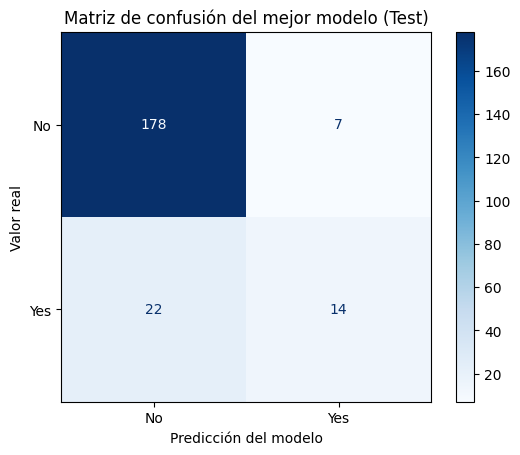

VN = 178   FP = 7
FN = 22   VP = 14


In [30]:
# b) Matriz de confusión:

# +++++++++ Inicia sección para incluir tu código ++++++++++++++++++++++++

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(np.ravel(ytestT), ypred_test)
VN, FP, FN, VP = cm.ravel()

ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Yes']).plot(cmap='Blues', values_format='d')
plt.title("Matriz de confusión del mejor modelo (Test)")
plt.xlabel("Predicción del modelo")
plt.ylabel("Valor real")
plt.show()

print("VN = %d   FP = %d" % (VN, FP))
print("FN = %d   VP = %d" % (FN, VP))

# +++++++++ Termina sección para incluir tu código ++++++++++++++++++++++++



*  c) Interpretación de VP, VF, FP, FN.
#### +++++++++ Inicia sección para incluir tus comentarios ++++++++++++++++++++++++


La clase positiva es Attrition = Yes (1): el empleado deja la compañía. El
conjunto de prueba tiene 221 empleados (185 que permanecieron y 36 que
renunciaron), que el modelo no utilizó durante el entrenamiento. La exactitud
en Test es de 86.9 % (192 aciertos de 221), superior al 83.7 % del modelo
ingenuo en este mismo conjunto (185 de 221).

* **VP:** Verdaderos Positivos = 14. Empleados que **sí renunciaron** y que
  el modelo identificó correctamente como en riesgo. Son los casos en los que
  la empresa habría podido intervenir a tiempo con acciones de retención.
  Representan solo 14 de los 36 que renunciaron (recall de 39 %).

* **VN:** Verdaderos Negativos = 178. Empleados que **permanecieron** en la
  compañía y que el modelo clasificó correctamente como de bajo riesgo. No
  requieren intervención ni generan costo. Son 178 de los 185 que
  permanecieron (96 %).

* **FP:** Falsos Positivos = 7. Empleados que **permanecieron**, pero que el
  modelo señaló como en riesgo de renunciar (falsas alarmas). Implican gastar
  recursos de retención en personas que no pensaban irse. De las 21 alertas
  que emite el modelo, 7 son falsas (precision de 67 %).

* **FN:** Falsos Negativos = 22. Empleados que **sí renunciaron**, pero que el
  modelo clasificó como de bajo riesgo. Es el error más costoso, como se
  argumentó en el Ejercicio 6e: la empresa no interviene y asume el costo
  completo de la salida. El modelo deja pasar a 22 de los 36 que renunciaron
  (61 %).

**Conclusión.** El modelo comete tres veces más Falsos Negativos (22) que
Falsos Positivos (7), justo el tipo de error identificado como más costoso.

Reconoce muy bien a quienes permanecen, pero detecta a menos de la mitad de
quienes renuncian. Esto confirma lo señalado en el Ejercicio 5e: con clases
desbalanceadas, optimizar la exactitud produce un modelo conservador que
favorece a la clase mayoritaria, por lo que serían más adecuadas métricas
como recall, F1 o G-mean, o bien ajustar el umbral de decisión o ponderar
las clases.

#### +++++++++ Termina sección para incluir tus comentarios ++++++++++++++++++++++++


Variables transformadas: 49 | Coeficientes anulados por la regularización: 8



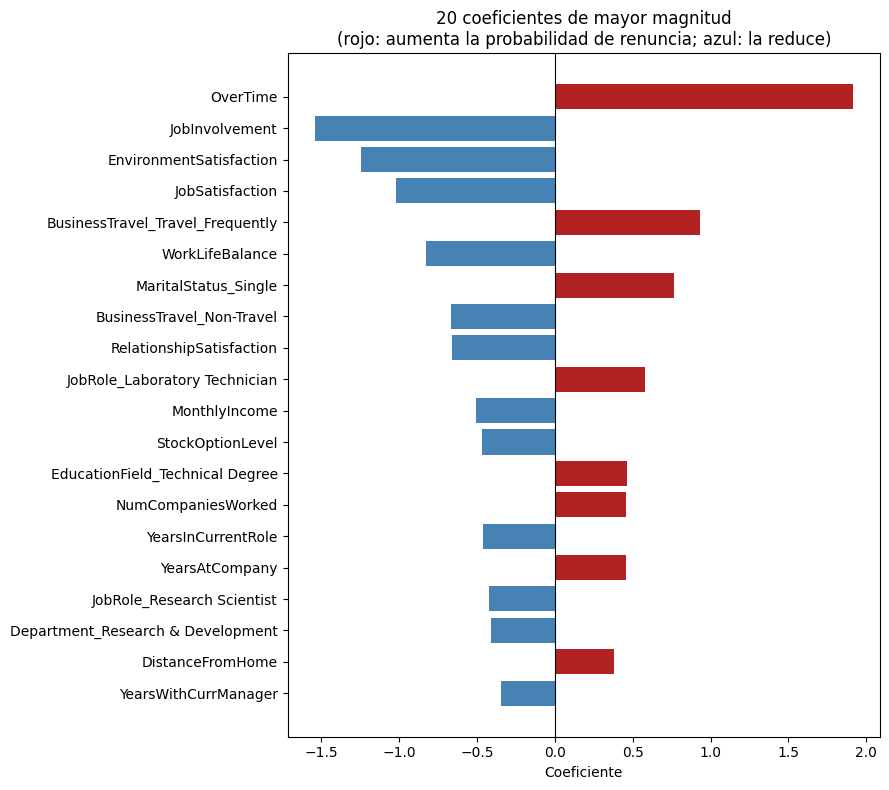

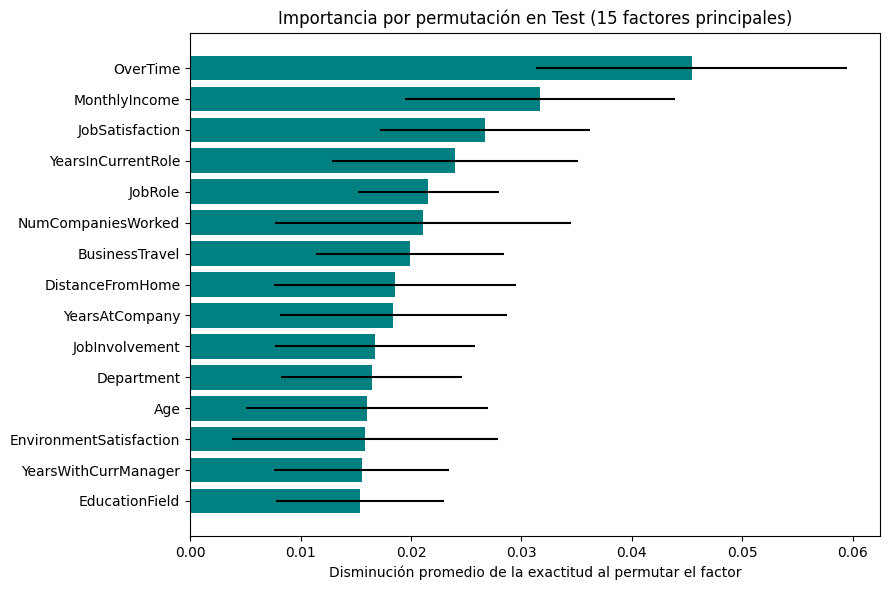

Coeficientes de mayor magnitud:
OverTime                             1.915
JobInvolvement                      -1.544
EnvironmentSatisfaction             -1.248
JobSatisfaction                     -1.019
BusinessTravel_Travel_Frequently     0.933
WorkLifeBalance                     -0.829
MaritalStatus_Single                 0.764
BusinessTravel_Non-Travel           -0.671
RelationshipSatisfaction            -0.660
JobRole_Laboratory Technician        0.576
MonthlyIncome                       -0.505
StockOptionLevel                    -0.468
EducationField_Technical Degree      0.463
NumCompaniesWorked                   0.459
YearsInCurrentRole                  -0.459
YearsAtCompany                       0.455
JobRole_Research Scientist          -0.421
Department_Research & Development   -0.414
DistanceFromHome                     0.382
YearsWithCurrManager                -0.343
dtype: float64

Importancia por permutación:
                         importancia    desv
OverTime          

In [31]:
# 10d) Inportancia de factores

# +++++++++ Inicia sección para incluir tu código ++++++++++++++++++++++++


from sklearn.inspection import permutation_importance

mejor = resultado_malla.best_estimator_

# d.1) Coeficientes de la regresión logística (variables ya transformadas)
nombres_t = mejor.named_steps['ct'].get_feature_names_out()
nombres_t = [n.split('__')[1] for n in nombres_t]
coefs = pd.Series(mejor.named_steps['m'].coef_.ravel(), index=nombres_t)

print("Variables transformadas: %d | Coeficientes anulados por la regularización: %d\n"
      % (len(coefs), (coefs == 0).sum()))

top = coefs.reindex(coefs.abs().sort_values(ascending=False).index).head(20)[::-1]
plt.figure(figsize=(9, 8))
plt.barh(top.index, top.values, color=['firebrick' if v > 0 else 'steelblue' for v in top.values])
plt.axvline(0, color='black', linewidth=0.8)
plt.title("20 coeficientes de mayor magnitud\n(rojo: aumenta la probabilidad de renuncia; azul: la reduce)")
plt.xlabel("Coeficiente")
plt.tight_layout()
plt.show()

# d.2) Importancia por permutación sobre los 30 factores originales (Test)
perm = permutation_importance(resultado_malla, Xtest, np.ravel(ytestT), scoring='accuracy',
                              n_repeats=30, random_state=1, n_jobs=-1)
imp = pd.DataFrame({'importancia': perm.importances_mean, 'desv': perm.importances_std},
                   index=Xtest.columns).sort_values('importancia', ascending=False)

top_p = imp.head(15)[::-1]
plt.figure(figsize=(9, 6))
plt.barh(top_p.index, top_p['importancia'], xerr=top_p['desv'], color='teal')
plt.title("Importancia por permutación en Test (15 factores principales)")
plt.xlabel("Disminución promedio de la exactitud al permutar el factor")
plt.tight_layout()
plt.show()

print("Coeficientes de mayor magnitud:")
print(top[::-1].round(3))
print("\nImportancia por permutación:")
print(imp.head(15).round(4))

# +++++++++ Termina sección para incluir tu código ++++++++++++++++++++++++



*  **10d) Comentarios sobre los resultados sobre el análisis de importancia de factores o características**

#### +++++++++ Inicia sección para incluir tus comentarios ++++++++++++++++++++++++

Se utilizaron dos análisis complementarios. Los **coeficientes** de la
regresión logística indican la dirección y magnitud del efecto de cada
variable transformada sobre la probabilidad de renuncia. La **importancia por
permutación** mide cuánto disminuye la exactitud en Test al desordenar los
valores de cada factor original, es decir, cuánto depende el modelo de él.

**Factor más importante.** `OverTime` ocupa el primer lugar en ambos
análisis. Su coeficiente (1.915) es el de mayor magnitud y equivale a
multiplicar por aproximadamente 6.8 los momios de renuncia (e^1.915) para
quien trabaja horas extra, manteniendo lo demás constante. Al permutarlo, la
exactitud en Test cae 4.5 puntos porcentuales, más que toda la ventaja del
modelo sobre el modelo ingenuo (86.9 % frente a 83.7 %).

**Factores que reducen el riesgo de renuncia (coeficiente negativo).**
Predominan las variables de satisfacción y compromiso: `JobInvolvement`
(-1.544), `EnvironmentSatisfaction` (-1.248), `JobSatisfaction` (-1.019),
`WorkLifeBalance` (-0.829) y `RelationshipSatisfaction` (-0.660). También
reducen el riesgo un mayor `MonthlyIncome` (-0.505), un mayor
`StockOptionLevel` (-0.468), más años en el puesto actual (-0.459) y con el
mismo jefe (-0.343), no viajar por trabajo (-0.671) y pertenecer al
departamento de Investigación y Desarrollo (-0.414).

**Factores que aumentan el riesgo (coeficiente positivo).** Además de las
horas extra: viajar con frecuencia (0.933), ser soltero (0.764), el puesto de
técnico de laboratorio (0.576), la formación en carrera técnica (0.463),
haber trabajado en más compañías (0.459) y vivir más lejos del trabajo
(0.382).

**Coincidencia entre ambos análisis.** `OverTime`, `MonthlyIncome`,
`JobSatisfaction`, `YearsInCurrentRole`, `JobRole`, `NumCompaniesWorked` y
`BusinessTravel` aparecen como relevantes en los dos, lo que da mayor
confianza sobre su importancia. En conjunto describen un perfil coherente con
la literatura sobre rotación: carga de trabajo, compensación, satisfacción y
estabilidad en el puesto.

**Efecto de la regularización.** De las 49 variables transformadas, 8
quedaron con coeficiente exactamente igual a cero y 41 se conservaron. La
componente L1 de Elastic Net realizó así una selección de variables
moderada, eliminando solo las que no aportan información adicional.

**Edad, género y estado civil.** En relación con el Ejercicio 3, el estado
civil sí resulta relevante: `MaritalStatus_Single` es el séptimo coeficiente
de mayor magnitud. `Age` aparece en la importancia por permutación (0.016),
aunque con una desviación estándar (0.011) que la hace poco concluyente.
`Gender` no figura entre los factores importantes. Por lo tanto, el modelo sí
se apoya en al menos una característica protegida, y no debería usarse para
decisiones individuales sobre empleados sin antes evaluar su exclusión y
auditar su equidad por grupo.

**Limitaciones.**
- Los coeficientes no son estrictamente comparables entre tipos de variable:
  las numéricas están estandarizadas (efecto por desviación estándar) y las
  ordinales y binarias están en [0, 1] (efecto del nivel mínimo al máximo).
  Esto explica que `MonthlyIncome` tenga un coeficiente moderado (-0.505) y
  sea, sin embargo, el segundo factor por permutación (0.032).
- Existe multicolinealidad entre las variables de antigüedad: `YearsAtCompany`
  tiene signo positivo (0.455) mientras `YearsInCurrentRole` (-0.459) y
  `YearsWithCurrManager` (-0.343) lo tienen negativo. Estos signos deben
  leerse en conjunto y con cautela, no de forma aislada.
- El conjunto de prueba es pequeño (221 registros): una importancia de 0.0045
  equivale a un solo empleado. Salvo `OverTime`, `MonthlyIncome`,
  `JobSatisfaction` y `JobRole`, la mayoría de las importancias están a menos
  de dos desviaciones estándar de cero, por lo que su orden exacto no es
  confiable.
- El modelo identifica asociaciones, no relaciones causales.

**Implicación práctica.** Los factores de mayor peso son en buena medida
gestionables por la empresa: horas extra, viajes frecuentes, satisfacción e
involucramiento, y compensación. Esto sugiere que las acciones de retención
deberían enfocarse en la carga de trabajo y las condiciones laborales, más
que en características personales del empleado.


#### +++++++++ Termina sección para incluir tus comentarios ++++++++++++++++++++++++

# **Ejercicio 11:**


### **Para terminar, responde las siguientes preguntas relacionadas con las implicaciones involucradas con la toma de decisiones basadas en los resultados de un modelo de aprendizaje automático. El objetivo es reflexionar sobre estas implicaciones y no dudes en compartir tus experiencias en caso de que te hayas enfrentado a una situación similar en tu trabajo.**

* **a) Si tu modelo predice e identifica con un alto porcentaje de exactitud quiénes de los colaboradores de la empresa estarán abandonando su puesto muy pronto, ¿cómo debería usarse esa información? Al responder, considera que es importante cuidar la parte ética y de privacidad de la información del colaborador.**

* **b) Con base a los resultados de la matriz de confusión, ¿qué tipo de error (FN o FP) está considerando como más costoso el modelo? En particular, ¿coincide con la respuesta que diste en el Ejercicio 6e?**

* **c) ¿Cómo comunicarías los resultados del modelo obtenido en esta actividad a un público no técnico, es decir, sin los conocimientos de temas de aprendizaje automático. Por ejemplo, supongamos que vas a comunicarle tus resultados a los directivos de la empresa o al personal del área de Recursos Humanos.**

* **d) ¿En cuáles ejercicios anteriores consideras que el (o los) modelo de lenguaje de gran tamaño LLM utilizado fue de mayor ayuda? ¿Por qué?**

* **e) Incluye tus conclusiones finales de la actividad.**

---

#### +++++++++ Inicia sección para incluir tus conclusiones ++++++++++++++++++++++++

**a)** La información debería usarse para **apoyar y retener** al
colaborador, nunca para perjudicarlo. En concreto:

- **Uso preventivo, no punitivo.** Una predicción de riesgo debe detonar
  acciones de apoyo: conversaciones de desarrollo, revisión de carga de
  trabajo, horas extra o compensación. No debe usarse para negar promociones,
  capacitación o proyectos, ni para anticipar un despido, ya que eso
  convertiría la predicción en una profecía autocumplida.
- **Prioridad al uso agregado.** El mayor valor está en identificar causas
  organizacionales (por ejemplo, áreas con exceso de horas extra o viajes) y
  corregirlas para todos, más que en señalar a personas concretas.
- **Decisión humana.** El modelo debe ser un insumo para Recursos Humanos, no
  un mecanismo automático. Es una probabilidad, no una certeza: en esta
  actividad, una de cada tres alertas fue una falsa alarma.
- **Privacidad y acceso restringido.** Los puntajes individuales deben
  conocerlos solo quienes los necesitan, no circular entre jefes directos sin
  control, y tratarse conforme a la legislación de protección de datos
  personales, con una finalidad legítima e informada.
- **Transparencia.** Los colaboradores deberían saber que existe este tipo de
  análisis y con qué propósito se utiliza.
- **Equidad.** Antes de usarlo deben excluirse o auditarse las
  características protegidas. En este modelo, el estado civil (soltero)
  resultó un factor relevante, lo que exige revisar si el modelo trata de
  forma desigual a ciertos grupos.


**b)** En la matriz de confusión del conjunto de prueba el modelo cometió
**22 Falsos Negativos y 7 Falsos Positivos**. Es decir, se comporta como si
el error más costoso fuera el **Falso Positivo**: evita generar falsas
alarmas a costa de dejar pasar a 22 de los 36 empleados que renunciaron
(recall de 39 %).

En sentido estricto, el modelo no asigna costos distintos a cada error: se
entrenó y seleccionó con la exactitud, que pesa por igual ambos tipos, y con
un umbral de decisión de 0.5. Sin embargo, como la clase "No" representa
cerca del 84 % de los datos, maximizar la exactitud favorece predecir "No" en
los casos dudosos, lo que en la práctica produce muchos más FN que FP.

**No coincide con la respuesta del Ejercicio 6e**, donde se argumentó que
para la empresa el error más costoso es el Falso Negativo. Existe, por lo
tanto, un desajuste entre el criterio con el que se optimizó el modelo y el
objetivo del negocio. Para alinearlos habría que optimizar una métrica que
priorice la detección de la clase positiva (recall, F1 o G-mean), ponderar
las clases (`class_weight='balanced'`), aplicar técnicas de remuestreo o
reducir el umbral de decisión por debajo de 0.5.


**c)** Evitaría los términos técnicos y presentaría los resultados en
función de personas, decisiones y limitaciones, con apoyo visual sencillo. El
mensaje sería aproximadamente el siguiente:

*"Desarrollamos una herramienta que, a partir de información laboral de cada
colaborador, estima quiénes tienen mayor riesgo de dejar la empresa. La
probamos con 221 colaboradores que la herramienta no conocía, de los cuales
36 renunciaron:*

- *Identificó correctamente a 14 de esos 36, es decir, cerca de 4 de cada 10.*
- *Cuando emite una alerta, acierta en 2 de cada 3 casos.*
- *No detectó a 22 personas que sí se fueron.*

*Esto significa que hoy la herramienta es confiable cuando señala a alguien,
pero todavía deja pasar a más de la mitad de quienes renuncian, por lo que no
debe ser el único criterio.*

*Lo más valioso es lo que nos dice sobre las causas. Los factores más
asociados con la salida son las horas extra, los viajes frecuentes, la baja
satisfacción e involucramiento con el trabajo y el nivel de ingreso. Son
aspectos sobre los que la empresa puede actuar."*

Cerraría con tres puntos: (1) recomendaciones concretas, como revisar la
política de horas extra y de viajes; (2) las limitaciones, aclarando que el
modelo muestra asociaciones y no causas, y que es un apoyo para la decisión
humana; y (3) los lineamientos éticos de uso. Usaría una gráfica de barras
con los factores principales y una figura con los 36 casos, en lugar de la
matriz de confusión o las métricas.


**d)** Se utilizó Claude (Anthropic). Fue de mayor ayuda en:

- **Ejercicios 6 y 7 (análisis exploratorio y transformaciones):** generó con
  rapidez el código de los gráficos y la estructura de `Pipeline` y
  `ColumnTransformer`, con una justificación para cada tipo de variable. Son
  tareas con mucha sintaxis repetitiva, donde el ahorro de tiempo es mayor.
- **Ejercicios 8 y 9 (ajuste de hiperparámetros):** ayudó a elegir los
  *solvers* compatibles con cada penalización y a diseñar la búsqueda de
  malla, incluyendo la comparación entre Train y Validation.
- **Ejercicio 10d (importancia de factores):** propuso combinar los
  coeficientes con la importancia por permutación y señaló limitaciones de
  interpretación que no habría considerado, como la multicolinealidad y la
  escala distinta de las variables.
- **Ejercicios de reflexión (3, 4 y 11):** sirvió para estructurar las ideas
  y ampliar los argumentos.

También tuvo limitaciones. No tiene acceso a los datos ni a la ejecución, por
lo que la interpretación de resultados solo fue posible cuando se le
proporcionaron las salidas reales. Además cometió un error en el Ejercicio 5:
su primera versión del `LabelEncoder` devolvía un arreglo en lugar del
DataFrame que requería el código del notebook, lo que generó un `IndexError`
que hubo que corregir. Esto muestra que el LLM acelera el trabajo, pero sus
respuestas deben ejecutarse, verificarse y entenderse; la validación y el
criterio siguen siendo responsabilidad de quien lo usa.


**e) Conclusiones**

1. **Proceso.** Se completó el flujo de un problema de clasificación: análisis
   exploratorio, partición estratificada, transformaciones por tipo de
   variable integradas en un pipeline para evitar el filtrado de información,
   comparación de modelos con validación cruzada, ajuste de hiperparámetros y
   evaluación final en un conjunto de prueba independiente.

2. **Modelos.** Las cuatro variantes de regresión logística superaron el
   umbral del modelo ingenuo (0.839) con desempeños prácticamente
   equivalentes (0.879 a 0.887), mientras que KNN quedó apenas por encima
   (0.845) y se consideró subentrenado. La regularización aportó poco, lo que
   indica que el problema no presenta un sobreajuste importante con estos
   modelos. Se eligió Elastic Net, que en Test obtuvo una exactitud de 0.869,
   consistente con la validación cruzada.

3. **La exactitud es insuficiente.** Aunque el modelo supera al ingenuo, solo
   detecta al 39 % de los empleados que renuncian y comete tres veces más
   Falsos Negativos (22) que Falsos Positivos (7). Es el aprendizaje
   principal de la actividad: con clases desbalanceadas, una exactitud alta
   puede ocultar un modelo de poca utilidad para el objetivo del negocio.

4. **Factores.** Las horas extra son el factor de mayor peso, seguidas del
   ingreso, la satisfacción e involucramiento con el trabajo, los viajes
   frecuentes y la estabilidad en el puesto. En su mayoría son aspectos que
   la empresa puede gestionar.

5. **Ética.** El estado civil resultó relevante para el modelo, lo que
   confirma las preocupaciones del Ejercicio 3. Un modelo de este tipo debe
   usarse para apoyar a los colaboradores y diagnosticar problemas
   organizacionales, con supervisión humana y cuidado de la privacidad.


6. **Limitaciones y trabajo futuro.** Los datos son sintéticos, el conjunto
   de prueba es pequeño (221 registros) y el modelo identifica asociaciones,
   no causas. Como siguientes pasos convendría optimizar métricas acordes con
   el costo de los errores (recall, F1, G-mean), ajustar el umbral de
   decisión o ponderar las clases, probar modelos no lineales y evaluar la
   equidad del modelo por grupos.

#### +++++++++ Termina sección para incluir tus conclusiones ++++++++++++++++++++++++



## Referencias

Anthropic. (2026). *Claude* (Claude Opus 5.5) [Modelo de lenguaje de gran
tamaño]. https://claude.ai

Pavansubhash. (s.f.). *IBM HR Analytics Employee Attrition & Performance*
[Conjunto de datos]. Kaggle. Recuperado el 4 de octubre de 2026, de
https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B.,
Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V.,
Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., y
Duchesnay, É. (2011). Scikit-learn: Machine learning in Python. *Journal of
Machine Learning Research, 12*(85), 2825–2830.
https://jmlr.org/papers/v12/pedregosa11a.html

scikit-learn developers. (2026a). *GridSearchCV*. scikit-learn 1.9.1
documentation. Recuperado el 4 de octubre de 2026, de
https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html

scikit-learn developers. (2026b). *LabelEncoder*. scikit-learn 1.9.1
documentation. Recuperado el 4 de octubre de 2026, de
https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html

scikit-learn developers. (2026c). *Permutation feature importance*.
scikit-learn 1.9.1 documentation. Recuperado el 4 de octubre de 2026, de
https://scikit-learn.org/stable/modules/permutation_importance.html

scikit-learn developers. (2026d). *RepeatedStratifiedKFold*. scikit-learn
1.9.1 documentation. Recuperado el 4 de octubre de 2026, de
https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RepeatedStratifiedKFold.html

# >> **Fin de la Actividad de Rotación de Personal de la Semana 3** <<